# NOTE:
# This notebook was originally executed from:
# /content/drive/MyDrive/notebooks/
# Paths may need to be adjusted if executed from a different directory.

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow import keras
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Concatenate



Connection to drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Getting the dataframe from the drive

In [ ]:
df3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/df3.csv')
df3

,Time,Front POA1 (W/m2),Front POA2 (W/m2),Rear 1 (W/m2),Rear 2 (W/m2),Rear 3 (W/m2),G,W,B,S,Temperatura C,Humedad_especifica g/kg,Precipitacion mm/hour,Humedad relativa %,tcc,tclw,sin_h,cos_h,sin_doy,cos_doy
0,2021-07-29 00:00:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,39.964287,0.153527,0.000000,1.000000,-0.455907,-0.890028
1,2021-07-29 00:15:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,35.300870,0.130069,0.000000,1.000000,-0.455907,-0.890028
2,2021-07-29 00:30:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,30.637451,0.106611,0.000000,1.000000,-0.455907,-0.890028
3,2021-07-29 00:45:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,25.974033,0.083153,0.000000,1.000000,-0.455907,-0.890028
4,2021-07-29 01:00:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.21,15.70,2.96,94.50,21.310616,0.059695,0.258819,0.965926,-0.455907,-0.890028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125659,2025-05-11 22:45:00,0.0,0.0,0.000331,0.00617,0.000835,0.0,0.0,1.0,0.0,17.28,10.68,0.00,88.15,98.551765,0.000439,-0.500000,0.866025,0.774884,-0.632103
125660,2025-05-11 23:00:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.412260,0.000063,-0.258819,0.965926,0.774884,-0.632103
125661,2025-05-11 23:15:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.502030,0.000048,-0.258819,0.965926,0.774884,-0.632103
125662,2025-05-11 23:30:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.591800,0.000033,-0.258819,0.965926,0.774884,-0.632103


Features of initial df

In [ ]:
df3.shape

(125664, 20)

In [ ]:
df3.dtypes

,0
Time,object
Front POA1 (W/m2),float64
Front POA2 (W/m2),float64
Rear 1 (W/m2),float64
Rear 2 (W/m2),float64
Rear 3 (W/m2),float64
G,float64
W,float64
B,float64
S,float64


In [ ]:
df3['Time']=pd.to_datetime(df3['Time'],format='%Y-%m-%d %H:%M:%S')


Vector of time gaps for window size=96 (1 day)

In [ ]:
time_gaps=[9888, 28416, 67584, 70272, 30144, 85440, 87264,87360, 97728, 105888]

Correlation

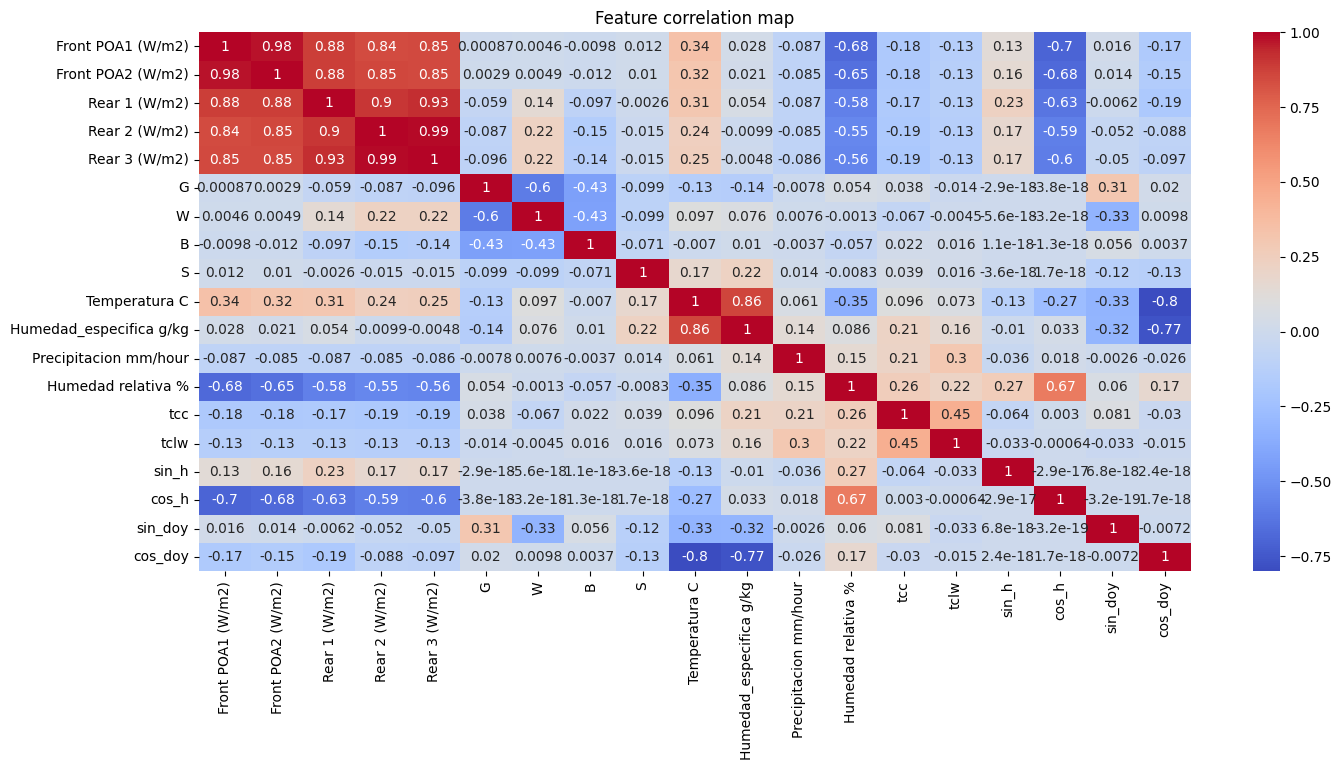

In [ ]:
data_corr=df3.select_dtypes(include=["float64"])
plt.figure(figsize=(16,7))
sns.heatmap(data_corr.corr(),annot=True,cmap="coolwarm")
plt.title("Feature correlation map")
plt.show()

Define seed

In [ ]:
import os
import random
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED']=str(42)

Define parameters

In [ ]:
n_exo_var=5  #[2,3,4,5],
#2=[T,relative_humidity],
#3=[T,relative_humidity,tcc],
#4=[T,relative_humidity, tcc ,precipitation]
#5=[T,relative_humidity, tcc, precipitation, specific humidity]
win_size=96 #[4,8,12,16,20,24,....,96,...192,...]
#It is the window that you want to predict, have in mind that t=15min, so win_size=4 means 1 hour
obs_window=384 #[96,192,288,384,480,576,672,...]
#It is the information of the past that you are using to predict
#obs_window=96,192,288, means 1 day, 2 days and 3 days respectively
gap_setting=0 #[96,192,288]
#it is the space (gap) between the last data and the start of horizon

Define window size for POA1 and POA2

In [ ]:
def df_to_x_y_poa(df_1D, window_size,lookback,n_exo,gap_set):
  df_ref=pd.DataFrame({'Irradiance':np.reshape(df_1D,(df_1D.shape[0]))})

  df_ref['temp']=df3['Temperatura C']
  df_ref['hum']=df3['Humedad relativa %']

  if n_exo==3:
    df_ref['tcc']=df3['tcc']
  if n_exo==4:
    df_ref['tcc']=df3['tcc']
    df_ref['prep']=df3['Precipitacion mm/hour']
  if n_exo==5:
    df_ref['tcc']=df3['tcc']
    df_ref['prep']=df3['Precipitacion mm/hour']
    df_ref['esp']=df3['Humedad_especifica g/kg']

  df_ref['sin_h']=df3['sin_h']
  df_ref['cos_h']=df3['cos_h']
  df_ref['sin_doy']=df3['sin_doy']
  df_ref['cos_doy']=df3['cos_doy']

  X=[]
  y=[]
  i=0
  #future data vs past data
  while i<=len(df_ref)-lookback-window_size-gap_set:
    if n_exo==2:
      X_past=df_ref[['Irradiance','temp','hum','sin_h','cos_h','sin_doy','cos_doy']][i:(i+lookback)].values

    if n_exo==3:
      X_past=df_ref[['Irradiance','temp','hum','tcc','sin_h','cos_h','sin_doy','cos_doy']][i:(i+lookback)].values

    if n_exo==4:
      X_past=df_ref[['Irradiance','temp','hum','tcc','prep','sin_h','cos_h','sin_doy','cos_doy']][i:(i+lookback)].values
    if n_exo==5:
      X_past=df_ref[['Irradiance','temp','hum','tcc','prep','esp','sin_h','cos_h','sin_doy','cos_doy']][i:(i+lookback)].values

    X.append(X_past)
    y.append(df_ref['Irradiance'][(i+lookback+gap_set):(lookback+window_size+i+gap_set)])

    if (lookback+window_size+i+gap_set) in time_gaps:
      if (lookback+window_size+i+gap_set)==87264:
        i=i+window_size*(2+int(lookback/window_size))

      else:
        i=i+window_size*(1+int(lookback/window_size))

    else:
      i=i+window_size


  return np.array(X),np.array(y)

X1_POA1,y1_POA1=df_to_x_y_poa(df3['Front POA1 (W/m2)'],window_size=win_size,lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting)
print(X1_POA1.shape)
X1_POA1=np.reshape(X1_POA1,(X1_POA1.shape[0],X1_POA1.shape[1],n_exo_var+5))
y1_POA1=np.reshape(y1_POA1,(y1_POA1.shape[0],y1_POA1.shape[1]))
print(X1_POA1.shape)
print(y1_POA1.shape)

(1268, 384, 10)
(1268, 384, 10)
(1268, 96)


In [ ]:
X1_POA2,y1_POA2=df_to_x_y_poa(df3['Front POA2 (W/m2)'],window_size=win_size,lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting)
X1_POA2=np.reshape(X1_POA2,(X1_POA2.shape[0],X1_POA2.shape[1],n_exo_var+5))
y1_POA2=np.reshape(y1_POA2,(y1_POA2.shape[0],y1_POA2.shape[1]))
print(X1_POA2.shape)
print(y1_POA2.shape)

(1268, 384, 10)
(1268, 96)


Define window size for Rear1, Rear2 and Rear3

In [ ]:
def df_to_x_y_rear(df_1D, window_size,lookback,n_exo,gap_set):
  df_ref=pd.DataFrame({'Irradiance':np.reshape(df_1D,(df_1D.shape[0]))})

  df_ref['temp']=df3['Temperatura C']
  df_ref['hum']=df3['Humedad relativa %']

  if n_exo==3:
    df_ref['tcc']=df3['tcc']
  if n_exo==4:
    df_ref['tcc']=df3['tcc']
    df_ref['prep']=df3['Precipitacion mm/hour']
  if n_exo==5:
    df_ref['tcc']=df3['tcc']
    df_ref['prep']=df3['Precipitacion mm/hour']
    df_ref['esp']=df3['Humedad_especifica g/kg']

  df_ref['sin_h']=df3['sin_h']
  df_ref['cos_h']=df3['cos_h']
  df_ref['sin_doy']=df3['sin_doy']
  df_ref['cos_doy']=df3['cos_doy']
  df_ref['G']=df3['G']
  df_ref['W']=df3['W']
  df_ref['B']=df3['B']
  df_ref['S']=df3['S']

  X=[]
  y=[]
  future_albedo=[]
  i=0
  #future data vs past data
  while i<=len(df_ref)-lookback-window_size-gap_set:
    if n_exo==2:
      X_past=df_ref[['Irradiance','temp','hum','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values

    if n_exo==3:
      X_past=df_ref[['Irradiance','temp','hum','tcc','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values

    if n_exo==4:
      X_past=df_ref[['Irradiance','temp','hum','tcc','prep','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values
    if n_exo==5:
      X_past=df_ref[['Irradiance','temp','hum','tcc','prep','esp','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values

    X.append(X_past)
    y.append(df_ref['Irradiance'][(i+lookback+gap_set):(lookback+window_size+i+gap_set)])
    future_albedo.append(df_ref[['G','W','B','S']].iloc[(i+lookback+gap_set+48),:])

    if (lookback+window_size+i+gap_set) in time_gaps:
      if (lookback+window_size+i+gap_set)==87264:
        i=i+window_size*(2+int(lookback/window_size))
      else:
        i=i+window_size*(1+int(lookback/window_size))
    else:
      i=i+window_size

  return np.array(X),np.array(y),np.array(future_albedo)

X1_Rear1,y1_Rear1,surfaces_Rear1=df_to_x_y_rear(df3['Rear 1 (W/m2)'],window_size=win_size,lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting)
X1_Rear1=np.reshape(X1_Rear1,(X1_Rear1.shape[0],X1_Rear1.shape[1],n_exo_var+9))
y1_Rear1=np.reshape(y1_Rear1,(y1_Rear1.shape[0],y1_Rear1.shape[1]))
print(X1_Rear1.shape)
print(y1_Rear1.shape)
print(surfaces_Rear1.shape)

(1268, 384, 14)
(1268, 96)
(1268, 4)


In [ ]:
X1_Rear2,y1_Rear2,surfaces_Rear2=df_to_x_y_rear(df3['Rear 2 (W/m2)'],window_size=win_size,lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting)
X1_Rear2=np.reshape(X1_Rear2,(X1_Rear2.shape[0],X1_Rear2.shape[1],n_exo_var+9))
y1_Rear2=np.reshape(y1_Rear2,(y1_Rear2.shape[0],y1_Rear2.shape[1]))
print(X1_Rear2.shape)
print(y1_Rear2.shape)
print(surfaces_Rear2.shape)

(1268, 384, 14)
(1268, 96)
(1268, 4)


In [ ]:
X1_Rear3,y1_Rear3,surfaces_Rear3=df_to_x_y_rear(df3['Rear 3 (W/m2)'],window_size=win_size,lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting)
X1_Rear3=np.reshape(X1_Rear3,(X1_Rear3.shape[0],X1_Rear3.shape[1],n_exo_var+9))
y1_Rear3=np.reshape(y1_Rear3,(y1_Rear3.shape[0],y1_Rear3.shape[1]))
print(X1_Rear3.shape)
print(y1_Rear3.shape)
print(surfaces_Rear3.shape)

(1268, 384, 14)
(1268, 96)
(1268, 4)


Define Training, validation and testing

In [ ]:
XR_POA1_train=X1_POA1[:int(X1_POA1.shape[0]*0.8)]
yR_POA1_train=y1_POA1[:int(y1_POA1.shape[0]*0.8)]

XR_POA1_val=X1_POA1[int(X1_POA1.shape[0]*0.8):int(X1_POA1.shape[0]*0.9)]
yR_POA1_val=y1_POA1[int(y1_POA1.shape[0]*0.8):int(y1_POA1.shape[0]*0.9)]

XR_POA1_test=X1_POA1[int(X1_POA1.shape[0]*0.9):]
yR_POA1_test=y1_POA1[int(y1_POA1.shape[0]*0.9):]

XR_POA1_train.shape,yR_POA1_train.shape,XR_POA1_val.shape,yR_POA1_val.shape,XR_POA1_test.shape,yR_POA1_test.shape

((1014, 384, 10),
 (1014, 96),
 (127, 384, 10),
 (127, 96),
 (127, 384, 10),
 (127, 96))

In [ ]:
XR_POA2_train=X1_POA2[:int(X1_POA2.shape[0]*0.8)]
yR_POA2_train=y1_POA2[:int(y1_POA2.shape[0]*0.8)]

XR_POA2_val=X1_POA2[int(X1_POA2.shape[0]*0.8):int(X1_POA2.shape[0]*0.9)]
yR_POA2_val=y1_POA2[int(y1_POA2.shape[0]*0.8):int(y1_POA2.shape[0]*0.9)]

XR_POA2_test=X1_POA2[int(X1_POA2.shape[0]*0.9):]
yR_POA2_test=y1_POA2[int(y1_POA2.shape[0]*0.9):]

XR_POA2_train.shape,yR_POA2_train.shape,XR_POA2_val.shape,yR_POA2_val.shape,XR_POA2_test.shape,yR_POA2_test.shape

((1014, 384, 10),
 (1014, 96),
 (127, 384, 10),
 (127, 96),
 (127, 384, 10),
 (127, 96))

In [ ]:
XR_Rear1_train=X1_Rear1[:int(X1_Rear1.shape[0]*0.8)]
yR_Rear1_train=y1_Rear1[:int(y1_Rear1.shape[0]*0.8)]
surf_Rear1_train=surfaces_Rear1[:int(surfaces_Rear1.shape[0]*0.8)]

XR_Rear1_val=X1_Rear1[int(X1_Rear1.shape[0]*0.8):int(X1_Rear1.shape[0]*0.9)]
yR_Rear1_val=y1_Rear1[int(y1_Rear1.shape[0]*0.8):int(y1_Rear1.shape[0]*0.9)]
surf_Rear1_val=surfaces_Rear1[int(surfaces_Rear1.shape[0]*0.8):int(surfaces_Rear1.shape[0]*0.9)]

XR_Rear1_test=X1_Rear1[int(X1_Rear1.shape[0]*0.9):]
yR_Rear1_test=y1_Rear1[int(y1_Rear1.shape[0]*0.9):]
surf_Rear1_test=surfaces_Rear1[int(surfaces_Rear1.shape[0]*0.9):]

XR_Rear1_train.shape,yR_Rear1_train.shape,XR_Rear1_val.shape,yR_Rear1_val.shape,XR_Rear1_test.shape,yR_Rear1_test.shape

((1014, 384, 14),
 (1014, 96),
 (127, 384, 14),
 (127, 96),
 (127, 384, 14),
 (127, 96))

In [ ]:
XR_Rear2_train=X1_Rear2[:int(X1_Rear2.shape[0]*0.8)]
yR_Rear2_train=y1_Rear2[:int(y1_Rear2.shape[0]*0.8)]
surf_Rear2_train=surfaces_Rear2[:int(surfaces_Rear2.shape[0]*0.8)]

XR_Rear2_val=X1_Rear2[int(X1_Rear2.shape[0]*0.8):int(X1_Rear2.shape[0]*0.9)]
yR_Rear2_val=y1_Rear2[int(y1_Rear2.shape[0]*0.8):int(y1_Rear2.shape[0]*0.9)]
surf_Rear2_val=surfaces_Rear2[int(surfaces_Rear2.shape[0]*0.8):int(surfaces_Rear2.shape[0]*0.9)]

XR_Rear2_test=X1_Rear2[int(X1_Rear2.shape[0]*0.9):]
yR_Rear2_test=y1_Rear2[int(y1_Rear2.shape[0]*0.9):]
surf_Rear2_test=surfaces_Rear2[int(surfaces_Rear2.shape[0]*0.9):]

XR_Rear2_train.shape,yR_Rear2_train.shape,XR_Rear2_val.shape,yR_Rear2_val.shape,XR_Rear2_test.shape,yR_Rear2_test.shape

((1014, 384, 14),
 (1014, 96),
 (127, 384, 14),
 (127, 96),
 (127, 384, 14),
 (127, 96))

In [ ]:
XR_Rear3_train=X1_Rear3[:int(X1_Rear3.shape[0]*0.8)]
yR_Rear3_train=y1_Rear3[:int(y1_Rear3.shape[0]*0.8)]
surf_Rear3_train=surfaces_Rear3[:int(surfaces_Rear3.shape[0]*0.8)]

XR_Rear3_val=X1_Rear3[int(X1_Rear3.shape[0]*0.8):int(X1_Rear3.shape[0]*0.9)]
yR_Rear3_val=y1_Rear3[int(y1_Rear3.shape[0]*0.8):int(y1_Rear3.shape[0]*0.9)]
surf_Rear3_val=surfaces_Rear3[int(surfaces_Rear3.shape[0]*0.8):int(surfaces_Rear3.shape[0]*0.9)]

XR_Rear3_test=X1_Rear3[int(X1_Rear3.shape[0]*0.9):]
yR_Rear3_test=y1_Rear3[int(y1_Rear3.shape[0]*0.9):]
surf_Rear3_test=surfaces_Rear3[int(surfaces_Rear3.shape[0]*0.9):]

XR_Rear3_train.shape,yR_Rear3_train.shape,XR_Rear3_val.shape,yR_Rear3_val.shape,XR_Rear3_test.shape,yR_Rear3_test.shape

((1014, 384, 14),
 (1014, 96),
 (127, 384, 14),
 (127, 96),
 (127, 384, 14),
 (127, 96))

Implement MinMaxScaler

In [ ]:
np_POA1_fit=XR_POA1_train[XR_POA1_train[:,:,0]>0.01]
np_POA2_fit=XR_POA2_train[XR_POA2_train[:,:,0]>0.01]
np_Rear1_fit=XR_Rear1_train[XR_Rear1_train[:,:,0]>0.01]
np_Rear2_fit=XR_Rear2_train[XR_Rear2_train[:,:,0]>0.01]
np_Rear3_fit=XR_Rear3_train[XR_Rear3_train[:,:,0]>0.01]


In [ ]:

scaler_POA1=MinMaxScaler().fit(np_POA1_fit.reshape(-1,1))
scaler_POA2=MinMaxScaler().fit(np_POA2_fit.reshape(-1,1))
scaler_Rear1=MinMaxScaler().fit(np_Rear1_fit.reshape(-1,1))
scaler_Rear2=MinMaxScaler().fit(np_Rear2_fit.reshape(-1,1))
scaler_Rear3=MinMaxScaler().fit(np_Rear3_fit.reshape(-1,1))
#If you use the same parameters (window_size,n_exo_var,obs_window) for POA and REAR
#Then you can normalize the other variables with one df
scaler_Temp=MinMaxScaler().fit(XR_POA1_train[:,:,1].reshape(-1,1))
scaler_Hum=MinMaxScaler().fit(XR_POA1_train[:,:,2].reshape(-1,1))

if n_exo_var==4:
  scaler_Prep=MinMaxScaler().fit(XR_POA1_train[:,:,4].reshape(-1,1))

if n_exo_var==5:
  scaler_Prep=MinMaxScaler().fit(XR_POA1_train[:,:,4].reshape(-1,1))
  scaler_esp=MinMaxScaler().fit(XR_POA1_train[:,:,5].reshape(-1,1))


In [ ]:

X1_POA1_train=XR_POA1_train
y1_POA1_train=yR_POA1_train
X1_POA2_train=XR_POA2_train
y1_POA2_train=yR_POA2_train
X1_Rear1_train=XR_Rear1_train
y1_Rear1_train=yR_Rear1_train
X1_Rear2_train=XR_Rear2_train
y1_Rear2_train=yR_Rear2_train
X1_Rear3_train=XR_Rear3_train
y1_Rear3_train=yR_Rear3_train

X1_POA1_val=XR_POA1_val
y1_POA1_val=yR_POA1_val
X1_POA2_val=XR_POA2_val
y1_POA2_val=yR_POA2_val
X1_Rear1_val=XR_Rear1_val
y1_Rear1_val=yR_Rear1_val
X1_Rear2_val=XR_Rear2_val
y1_Rear2_val=yR_Rear2_val
X1_Rear3_val=XR_Rear3_val
y1_Rear3_val=yR_Rear3_val

X1_POA1_test=XR_POA1_test
X1_POA2_test=XR_POA2_test
X1_Rear1_test=XR_Rear1_test
X1_Rear2_test=XR_Rear2_test
X1_Rear3_test=XR_Rear3_test

Transform with the scalers created

In [ ]:
X1_POA1_train[:,:,0]=(scaler_POA1.transform(XR_POA1_train[:,:,0].reshape(-1,1))).reshape(XR_POA1_train.shape[0],XR_POA1_train.shape[1])
y1_POA1_train[:,:]=(scaler_POA1.transform(yR_POA1_train[:,:].reshape(-1,1))).reshape(yR_POA1_train.shape[0],yR_POA1_train.shape[1])

X1_POA1_val[:,:,0]=(scaler_POA1.transform(XR_POA1_val[:,:,0].reshape(-1,1))).reshape(XR_POA1_val.shape[0],XR_POA1_val.shape[1])
y1_POA1_val[:,:]=(scaler_POA1.transform(yR_POA1_val[:,:].reshape(-1,1))).reshape(yR_POA1_val.shape[0],yR_POA1_val.shape[1])

X1_POA1_test[:,:,0]=(scaler_POA1.transform(XR_POA1_test[:,:,0].reshape(-1,1))).reshape(XR_POA1_test.shape[0],XR_POA1_test.shape[1])

X1_POA1_train[:,:,1]=(scaler_Temp.transform(XR_POA1_train[:,:,1].reshape(-1,1))).reshape(XR_POA1_train.shape[0],XR_POA1_train.shape[1])
X1_POA1_val[:,:,1]=(scaler_Temp.transform(XR_POA1_val[:,:,1].reshape(-1,1))).reshape(XR_POA1_val.shape[0],XR_POA1_val.shape[1])

X1_POA1_test[:,:,1]=(scaler_Temp.transform(XR_POA1_test[:,:,1].reshape(-1,1))).reshape(XR_POA1_test.shape[0],XR_POA1_test.shape[1])

X1_POA1_train[:,:,2]=(scaler_Hum.transform(XR_POA1_train[:,:,2].reshape(-1,1))).reshape(XR_POA1_train.shape[0],XR_POA1_train.shape[1])
X1_POA1_val[:,:,2]=(scaler_Hum.transform(XR_POA1_val[:,:,2].reshape(-1,1))).reshape(XR_POA1_val.shape[0],XR_POA1_val.shape[1])

X1_POA1_test[:,:,2]=(scaler_Hum.transform(XR_POA1_test[:,:,2].reshape(-1,1))).reshape(XR_POA1_test.shape[0],XR_POA1_test.shape[1])

if n_exo_var==3:
  X1_POA1_train[:,:,3]=XR_POA1_train[:,:,3]/100
  X1_POA1_val[:,:,3]=XR_POA1_val[:,:,3]/100
  X1_POA1_test[:,:,3]=XR_POA1_test[:,:,3]/100

if n_exo_var==4:
  X1_POA1_train[:,:,3]=XR_POA1_train[:,:,3]/100
  X1_POA1_val[:,:,3]=XR_POA1_val[:,:,3]/100
  X1_POA1_test[:,:,3]=XR_POA1_test[:,:,3]/100
  X1_POA1_train[:,:,4]=(scaler_Prep.transform(XR_POA1_train[:,:,4].reshape(-1,1))).reshape(XR_POA1_train.shape[0],XR_POA1_train.shape[1])
  X1_POA1_val[:,:,4]=(scaler_Prep.transform(XR_POA1_val[:,:,4].reshape(-1,1))).reshape(XR_POA1_val.shape[0],XR_POA1_val.shape[1])
  X1_POA1_test[:,:,4]=(scaler_Prep.transform(XR_POA1_test[:,:,4].reshape(-1,1))).reshape(XR_POA1_test.shape[0],XR_POA1_test.shape[1])
if n_exo_var==5:
  X1_POA1_train[:,:,3]=XR_POA1_train[:,:,3]/100
  X1_POA1_val[:,:,3]=XR_POA1_val[:,:,3]/100
  X1_POA1_test[:,:,3]=XR_POA1_test[:,:,3]/100
  X1_POA1_train[:,:,4]=(scaler_Prep.transform(XR_POA1_train[:,:,4].reshape(-1,1))).reshape(XR_POA1_train.shape[0],XR_POA1_train.shape[1])
  X1_POA1_val[:,:,4]=(scaler_Prep.transform(XR_POA1_val[:,:,4].reshape(-1,1))).reshape(XR_POA1_val.shape[0],XR_POA1_val.shape[1])
  X1_POA1_test[:,:,4]=(scaler_Prep.transform(XR_POA1_test[:,:,4].reshape(-1,1))).reshape(XR_POA1_test.shape[0],XR_POA1_test.shape[1])
  X1_POA1_train[:,:,5]=(scaler_esp.transform(XR_POA1_train[:,:,5].reshape(-1,1))).reshape(XR_POA1_train.shape[0],XR_POA1_train.shape[1])
  X1_POA1_val[:,:,5]=(scaler_esp.transform(XR_POA1_val[:,:,5].reshape(-1,1))).reshape(XR_POA1_val.shape[0],XR_POA1_val.shape[1])
  X1_POA1_test[:,:,5]=(scaler_esp.transform(XR_POA1_test[:,:,5].reshape(-1,1))).reshape(XR_POA1_test.shape[0],XR_POA1_test.shape[1])


In [ ]:
X1_POA2_train[:,:,0]=(scaler_POA2.transform(XR_POA2_train[:,:,0].reshape(-1,1))).reshape(XR_POA2_train.shape[0],XR_POA2_train.shape[1])
y1_POA2_train[:,:]=(scaler_POA2.transform(yR_POA2_train[:,:].reshape(-1,1))).reshape(yR_POA2_train.shape[0],yR_POA2_train.shape[1])

X1_POA2_val[:,:,0]=(scaler_POA2.transform(XR_POA2_val[:,:,0].reshape(-1,1))).reshape(XR_POA2_val.shape[0],XR_POA2_val.shape[1])
y1_POA2_val[:,:]=(scaler_POA2.transform(yR_POA2_val[:,:].reshape(-1,1))).reshape(yR_POA2_val.shape[0],yR_POA2_val.shape[1])

X1_POA2_test[:,:,0]=(scaler_POA2.transform(XR_POA2_test[:,:,0].reshape(-1,1))).reshape(XR_POA2_test.shape[0],XR_POA2_test.shape[1])

X1_POA2_train[:,:,1]=(scaler_Temp.transform(XR_POA2_train[:,:,1].reshape(-1,1))).reshape(XR_POA2_train.shape[0],XR_POA2_train.shape[1])
X1_POA2_val[:,:,1]=(scaler_Temp.transform(XR_POA2_val[:,:,1].reshape(-1,1))).reshape(XR_POA2_val.shape[0],XR_POA2_val.shape[1])

X1_POA2_test[:,:,1]=(scaler_Temp.transform(XR_POA2_test[:,:,1].reshape(-1,1))).reshape(XR_POA2_test.shape[0],XR_POA2_test.shape[1])

X1_POA2_train[:,:,2]=(scaler_Hum.transform(XR_POA2_train[:,:,2].reshape(-1,1))).reshape(XR_POA2_train.shape[0],XR_POA2_train.shape[1])
X1_POA2_val[:,:,2]=(scaler_Hum.transform(XR_POA2_val[:,:,2].reshape(-1,1))).reshape(XR_POA2_val.shape[0],XR_POA2_val.shape[1])

X1_POA2_test[:,:,2]=(scaler_Hum.transform(XR_POA2_test[:,:,2].reshape(-1,1))).reshape(XR_POA2_test.shape[0],XR_POA2_test.shape[1])
if n_exo_var==3:
  X1_POA2_train[:,:,3]=XR_POA2_train[:,:,3]/100
  X1_POA2_val[:,:,3]=XR_POA2_val[:,:,3]/100
  X1_POA2_test[:,:,3]=XR_POA2_test[:,:,3]/100
if n_exo_var==4:
  X1_POA2_train[:,:,3]=XR_POA2_train[:,:,3]/100
  X1_POA2_val[:,:,3]=XR_POA2_val[:,:,3]/100
  X1_POA2_test[:,:,3]=XR_POA2_test[:,:,3]/100
  X1_POA2_train[:,:,4]=(scaler_Prep.transform(XR_POA2_train[:,:,4].reshape(-1,1))).reshape(XR_POA2_train.shape[0],XR_POA2_train.shape[1])
  X1_POA2_val[:,:,4]=(scaler_Prep.transform(XR_POA2_val[:,:,4].reshape(-1,1))).reshape(XR_POA2_val.shape[0],XR_POA2_val.shape[1])
  X1_POA2_test[:,:,4]=(scaler_Prep.transform(XR_POA2_test[:,:,4].reshape(-1,1))).reshape(XR_POA2_test.shape[0],XR_POA2_test.shape[1])
if n_exo_var==5:
  X1_POA2_train[:,:,3]=XR_POA2_train[:,:,3]/100
  X1_POA2_val[:,:,3]=XR_POA2_val[:,:,3]/100
  X1_POA2_test[:,:,3]=XR_POA2_test[:,:,3]/100
  X1_POA2_train[:,:,4]=(scaler_Prep.transform(XR_POA2_train[:,:,4].reshape(-1,1))).reshape(XR_POA2_train.shape[0],XR_POA2_train.shape[1])
  X1_POA2_val[:,:,4]=(scaler_Prep.transform(XR_POA2_val[:,:,4].reshape(-1,1))).reshape(XR_POA2_val.shape[0],XR_POA2_val.shape[1])
  X1_POA2_test[:,:,4]=(scaler_Prep.transform(XR_POA2_test[:,:,4].reshape(-1,1))).reshape(XR_POA2_test.shape[0],XR_POA2_test.shape[1])
  X1_POA2_train[:,:,5]=(scaler_esp.transform(XR_POA2_train[:,:,5].reshape(-1,1))).reshape(XR_POA2_train.shape[0],XR_POA2_train.shape[1])
  X1_POA2_val[:,:,5]=(scaler_esp.transform(XR_POA2_val[:,:,5].reshape(-1,1))).reshape(XR_POA2_val.shape[0],XR_POA2_val.shape[1])
  X1_POA2_test[:,:,5]=(scaler_esp.transform(XR_POA2_test[:,:,5].reshape(-1,1))).reshape(XR_POA2_test.shape[0],XR_POA2_test.shape[1])

In [ ]:
X1_Rear1_train[:,:,0]=(scaler_Rear1.transform(XR_Rear1_train[:,:,0].reshape(-1,1))).reshape(XR_Rear1_train.shape[0],XR_Rear1_train.shape[1])
y1_Rear1_train[:,:]=(scaler_Rear1.transform(yR_Rear1_train[:,:].reshape(-1,1))).reshape(yR_Rear1_train.shape[0],yR_Rear1_train.shape[1])

X1_Rear1_val[:,:,0]=(scaler_Rear1.transform(XR_Rear1_val[:,:,0].reshape(-1,1))).reshape(XR_Rear1_val.shape[0],XR_Rear1_val.shape[1])
y1_Rear1_val[:,:]=(scaler_Rear1.transform(yR_Rear1_val[:,:].reshape(-1,1))).reshape(yR_Rear1_val.shape[0],yR_Rear1_val.shape[1])

X1_Rear1_test[:,:,0]=(scaler_Rear1.transform(XR_Rear1_test[:,:,0].reshape(-1,1))).reshape(XR_Rear1_test.shape[0],XR_Rear1_test.shape[1])

X1_Rear1_train[:,:,1]=(scaler_Temp.transform(XR_Rear1_train[:,:,1].reshape(-1,1))).reshape(XR_Rear1_train.shape[0],XR_Rear1_train.shape[1])
X1_Rear1_val[:,:,1]=(scaler_Temp.transform(XR_Rear1_val[:,:,1].reshape(-1,1))).reshape(XR_Rear1_val.shape[0],XR_Rear1_val.shape[1])

X1_Rear1_test[:,:,1]=(scaler_Temp.transform(XR_Rear1_test[:,:,1].reshape(-1,1))).reshape(XR_Rear1_test.shape[0],XR_Rear1_test.shape[1])

X1_Rear1_train[:,:,2]=(scaler_Hum.transform(XR_Rear1_train[:,:,2].reshape(-1,1))).reshape(XR_Rear1_train.shape[0],XR_Rear1_train.shape[1])
X1_Rear1_val[:,:,2]=(scaler_Hum.transform(XR_Rear1_val[:,:,2].reshape(-1,1))).reshape(XR_Rear1_val.shape[0],XR_Rear1_val.shape[1])

X1_Rear1_test[:,:,2]=(scaler_Hum.transform(XR_Rear1_test[:,:,2].reshape(-1,1))).reshape(XR_Rear1_test.shape[0],XR_Rear1_test.shape[1])

if n_exo_var==3:
  X1_Rear1_train[:,:,3]=(XR_Rear1_train[:,:,3]/100)
  X1_Rear1_val[:,:,3]=(XR_Rear1_val[:,:,3]/100)
  X1_Rear1_test[:,:,3]=(XR_Rear1_test[:,:,3]/100)
if n_exo_var==4:
  X1_Rear1_train[:,:,3]=(XR_Rear1_train[:,:,3]/100)
  X1_Rear1_val[:,:,3]=(XR_Rear1_val[:,:,3]/100)
  X1_Rear1_test[:,:,3]=(XR_Rear1_test[:,:,3]/100)
  X1_Rear1_train[:,:,4]=(scaler_Prep.transform(XR_Rear1_train[:,:,4].reshape(-1,1))).reshape(XR_Rear1_train.shape[0],XR_Rear1_train.shape[1])
  X1_Rear1_val[:,:,4]=(scaler_Prep.transform(XR_Rear1_val[:,:,4].reshape(-1,1))).reshape(XR_Rear1_val.shape[0],XR_Rear1_val.shape[1])
  X1_Rear1_test[:,:,4]=(scaler_Prep.transform(XR_Rear1_test[:,:,4].reshape(-1,1))).reshape(XR_Rear1_test.shape[0],XR_Rear1_test.shape[1])

if n_exo_var==5:
  X1_Rear1_train[:,:,3]=(XR_Rear1_train[:,:,3]/100)
  X1_Rear1_val[:,:,3]=(XR_Rear1_val[:,:,3]/100)
  X1_Rear1_test[:,:,3]=(XR_Rear1_test[:,:,3]/100)
  X1_Rear1_train[:,:,4]=(scaler_Prep.transform(XR_Rear1_train[:,:,4].reshape(-1,1))).reshape(XR_Rear1_train.shape[0],XR_Rear1_train.shape[1])
  X1_Rear1_val[:,:,4]=(scaler_Prep.transform(XR_Rear1_val[:,:,4].reshape(-1,1))).reshape(XR_Rear1_val.shape[0],XR_Rear1_val.shape[1])
  X1_Rear1_test[:,:,4]=(scaler_Prep.transform(XR_Rear1_test[:,:,4].reshape(-1,1))).reshape(XR_Rear1_test.shape[0],XR_Rear1_test.shape[1])
  X1_Rear1_train[:,:,5]=(scaler_esp.transform(XR_Rear1_train[:,:,5].reshape(-1,1))).reshape(XR_Rear1_train.shape[0],XR_Rear1_train.shape[1])
  X1_Rear1_val[:,:,5]=(scaler_esp.transform(XR_Rear1_val[:,:,5].reshape(-1,1))).reshape(XR_Rear1_val.shape[0],XR_Rear1_val.shape[1])
  X1_Rear1_test[:,:,5]=(scaler_esp.transform(XR_Rear1_test[:,:,5].reshape(-1,1))).reshape(XR_Rear1_test.shape[0],XR_Rear1_test.shape[1])

#

In [ ]:
X1_Rear2_train[:,:,0]=(scaler_Rear2.transform(XR_Rear2_train[:,:,0].reshape(-1,1))).reshape(XR_Rear2_train.shape[0],XR_Rear2_train.shape[1])
y1_Rear2_train[:,:]=(scaler_Rear2.transform(yR_Rear2_train[:,:].reshape(-1,1))).reshape(yR_Rear2_train.shape[0],yR_Rear2_train.shape[1])

X1_Rear2_val[:,:,0]=(scaler_Rear2.transform(XR_Rear2_val[:,:,0].reshape(-1,1))).reshape(XR_Rear2_val.shape[0],XR_Rear2_val.shape[1])
y1_Rear2_val[:,:]=(scaler_Rear2.transform(yR_Rear2_val[:,:].reshape(-1,1))).reshape(yR_Rear2_val.shape[0],yR_Rear2_val.shape[1])

X1_Rear2_test[:,:,0]=(scaler_Rear2.transform(XR_Rear2_test[:,:,0].reshape(-1,1))).reshape(XR_Rear2_test.shape[0],XR_Rear2_test.shape[1])

X1_Rear2_train[:,:,1]=(scaler_Temp.transform(XR_Rear2_train[:,:,1].reshape(-1,1))).reshape(XR_Rear2_train.shape[0],XR_Rear2_train.shape[1])
X1_Rear2_val[:,:,1]=(scaler_Temp.transform(XR_Rear2_val[:,:,1].reshape(-1,1))).reshape(XR_Rear2_val.shape[0],XR_Rear2_val.shape[1])

X1_Rear2_test[:,:,1]=(scaler_Temp.transform(XR_Rear2_test[:,:,1].reshape(-1,1))).reshape(XR_Rear2_test.shape[0],XR_Rear2_test.shape[1])

X1_Rear2_train[:,:,2]=(scaler_Hum.transform(XR_Rear2_train[:,:,2].reshape(-1,1))).reshape(XR_Rear2_train.shape[0],XR_Rear2_train.shape[1])
X1_Rear2_val[:,:,2]=(scaler_Hum.transform(XR_Rear2_val[:,:,2].reshape(-1,1))).reshape(XR_Rear2_val.shape[0],XR_Rear2_val.shape[1])

X1_Rear2_test[:,:,2]=(scaler_Hum.transform(XR_Rear2_test[:,:,2].reshape(-1,1))).reshape(XR_Rear2_test.shape[0],XR_Rear2_test.shape[1])

if n_exo_var==3:
  X1_Rear2_train[:,:,3]=(XR_Rear2_train[:,:,3]/100)
  X1_Rear2_val[:,:,3]=(XR_Rear2_val[:,:,3]/100)
  X1_Rear2_test[:,:,3]=(XR_Rear2_test[:,:,3]/100)
if n_exo_var==4:
  X1_Rear2_train[:,:,3]=(XR_Rear2_train[:,:,3]/100)
  X1_Rear2_val[:,:,3]=(XR_Rear2_val[:,:,3]/100)
  X1_Rear2_test[:,:,3]=(XR_Rear2_test[:,:,3]/100)
  X1_Rear2_train[:,:,4]=(scaler_Prep.transform(XR_Rear2_train[:,:,4].reshape(-1,1))).reshape(XR_Rear2_train.shape[0],XR_Rear2_train.shape[1])
  X1_Rear2_val[:,:,4]=(scaler_Prep.transform(XR_Rear2_val[:,:,4].reshape(-1,1))).reshape(XR_Rear2_val.shape[0],XR_Rear2_val.shape[1])
  X1_Rear2_test[:,:,4]=(scaler_Prep.transform(XR_Rear2_test[:,:,4].reshape(-1,1))).reshape(XR_Rear2_test.shape[0],XR_Rear2_test.shape[1])

if n_exo_var==5:
  X1_Rear2_train[:,:,3]=(XR_Rear2_train[:,:,3]/100)
  X1_Rear2_val[:,:,3]=(XR_Rear2_val[:,:,3]/100)
  X1_Rear2_test[:,:,3]=(XR_Rear2_test[:,:,3]/100)
  X1_Rear2_train[:,:,4]=(scaler_Prep.transform(XR_Rear2_train[:,:,4].reshape(-1,1))).reshape(XR_Rear2_train.shape[0],XR_Rear2_train.shape[1])
  X1_Rear2_val[:,:,4]=(scaler_Prep.transform(XR_Rear2_val[:,:,4].reshape(-1,1))).reshape(XR_Rear2_val.shape[0],XR_Rear2_val.shape[1])
  X1_Rear2_test[:,:,4]=(scaler_Prep.transform(XR_Rear2_test[:,:,4].reshape(-1,1))).reshape(XR_Rear2_test.shape[0],XR_Rear2_test.shape[1])
  X1_Rear2_train[:,:,5]=(scaler_esp.transform(XR_Rear2_train[:,:,5].reshape(-1,1))).reshape(XR_Rear2_train.shape[0],XR_Rear2_train.shape[1])
  X1_Rear2_val[:,:,5]=(scaler_esp.transform(XR_Rear2_val[:,:,5].reshape(-1,1))).reshape(XR_Rear2_val.shape[0],XR_Rear2_val.shape[1])
  X1_Rear2_test[:,:,5]=(scaler_esp.transform(XR_Rear2_test[:,:,5].reshape(-1,1))).reshape(XR_Rear2_test.shape[0],XR_Rear2_test.shape[1])
#

In [ ]:
X1_Rear3_train[:,:,0]=(scaler_Rear3.transform(XR_Rear3_train[:,:,0].reshape(-1,1))).reshape(XR_Rear3_train.shape[0],XR_Rear3_train.shape[1])
y1_Rear3_train[:,:]=(scaler_Rear3.transform(yR_Rear3_train[:,:].reshape(-1,1))).reshape(yR_Rear3_train.shape[0],yR_Rear3_train.shape[1])

X1_Rear3_val[:,:,0]=(scaler_Rear3.transform(XR_Rear3_val[:,:,0].reshape(-1,1))).reshape(XR_Rear3_val.shape[0],XR_Rear3_val.shape[1])
y1_Rear3_val[:,:]=(scaler_Rear3.transform(yR_Rear3_val[:,:].reshape(-1,1))).reshape(yR_Rear3_val.shape[0],yR_Rear3_val.shape[1])

X1_Rear3_test[:,:,0]=(scaler_Rear3.transform(XR_Rear3_test[:,:,0].reshape(-1,1))).reshape(XR_Rear3_test.shape[0],XR_Rear3_test.shape[1])

X1_Rear3_train[:,:,1]=(scaler_Temp.transform(XR_Rear3_train[:,:,1].reshape(-1,1))).reshape(XR_Rear3_train.shape[0],XR_Rear3_train.shape[1])
X1_Rear3_val[:,:,1]=(scaler_Temp.transform(XR_Rear3_val[:,:,1].reshape(-1,1))).reshape(XR_Rear3_val.shape[0],XR_Rear3_val.shape[1])

X1_Rear3_test[:,:,1]=(scaler_Temp.transform(XR_Rear3_test[:,:,1].reshape(-1,1))).reshape(XR_Rear3_test.shape[0],XR_Rear3_test.shape[1])

X1_Rear3_train[:,:,2]=(scaler_Hum.transform(XR_Rear3_train[:,:,2].reshape(-1,1))).reshape(XR_Rear3_train.shape[0],XR_Rear3_train.shape[1])
X1_Rear3_val[:,:,2]=(scaler_Hum.transform(XR_Rear3_val[:,:,2].reshape(-1,1))).reshape(XR_Rear3_val.shape[0],XR_Rear3_val.shape[1])

X1_Rear3_test[:,:,2]=(scaler_Hum.transform(XR_Rear3_test[:,:,2].reshape(-1,1))).reshape(XR_Rear3_test.shape[0],XR_Rear3_test.shape[1])

if n_exo_var==3:
  X1_Rear3_train[:,:,3]=(XR_Rear3_train[:,:,3]/100)
  X1_Rear3_val[:,:,3]=(XR_Rear3_val[:,:,3]/100)
  X1_Rear3_test[:,:,3]=(XR_Rear3_test[:,:,3]/100)
if n_exo_var==4:
  X1_Rear3_train[:,:,3]=(XR_Rear3_train[:,:,3]/100)
  X1_Rear3_val[:,:,3]=(XR_Rear3_val[:,:,3]/100)
  X1_Rear3_test[:,:,3]=(XR_Rear3_test[:,:,3]/100)
  X1_Rear3_train[:,:,4]=(scaler_Prep.transform(XR_Rear3_train[:,:,4].reshape(-1,1))).reshape(XR_Rear3_train.shape[0],XR_Rear3_train.shape[1])
  X1_Rear3_val[:,:,4]=(scaler_Prep.transform(XR_Rear3_val[:,:,4].reshape(-1,1))).reshape(XR_Rear3_val.shape[0],XR_Rear3_val.shape[1])
  X1_Rear3_test[:,:,4]=(scaler_Prep.transform(XR_Rear3_test[:,:,4].reshape(-1,1))).reshape(XR_Rear3_test.shape[0],XR_Rear3_test.shape[1])
if n_exo_var==5:
  X1_Rear3_train[:,:,3]=(XR_Rear3_train[:,:,3]/100)
  X1_Rear3_val[:,:,3]=(XR_Rear3_val[:,:,3]/100)
  X1_Rear3_test[:,:,3]=(XR_Rear3_test[:,:,3]/100)
  X1_Rear3_train[:,:,4]=(scaler_Prep.transform(XR_Rear3_train[:,:,4].reshape(-1,1))).reshape(XR_Rear3_train.shape[0],XR_Rear3_train.shape[1])
  X1_Rear3_val[:,:,4]=(scaler_Prep.transform(XR_Rear3_val[:,:,4].reshape(-1,1))).reshape(XR_Rear3_val.shape[0],XR_Rear3_val.shape[1])
  X1_Rear3_test[:,:,4]=(scaler_Prep.transform(XR_Rear3_test[:,:,4].reshape(-1,1))).reshape(XR_Rear3_test.shape[0],XR_Rear3_test.shape[1])
  X1_Rear3_train[:,:,5]=(scaler_esp.transform(XR_Rear3_train[:,:,5].reshape(-1,1))).reshape(XR_Rear3_train.shape[0],XR_Rear3_train.shape[1])
  X1_Rear3_val[:,:,5]=(scaler_esp.transform(XR_Rear3_val[:,:,5].reshape(-1,1))).reshape(XR_Rear3_val.shape[0],XR_Rear3_val.shape[1])
  X1_Rear3_test[:,:,5]=(scaler_esp.transform(XR_Rear3_test[:,:,5].reshape(-1,1))).reshape(XR_Rear3_test.shape[0],XR_Rear3_test.shape[1])

#

Import keras-tuner

In [ ]:
pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.1 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt
from keras_tuner import BayesianOptimization

Define Callbacks

In [ ]:

early_stop1=EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True)
check_point_poa1=ModelCheckpoint(filepath="model_checkpoint/best_model_poa1.keras",monitor='mae',save_best_only=True)

Define function to optimize hyperparameters

In [ ]:
def create_model_tun_poa(hp):
  model1_trial=keras.models.Sequential()
  model1_trial.add(keras.layers.GRU(units=hp.Choice('units1',[64,128]),return_sequences=True,
                                     activation='tanh',input_shape=((obs_window),(5+n_exo_var))))
  model1_trial.add(keras.layers.Dropout(hp.Choice('drop1',[0.1,0.2,0.3])))
  model1_trial.add(keras.layers.GRU(units=hp.Choice('units2',[32,64,128]),return_sequences=False))
  model1_trial.add(keras.layers.Dropout(hp.Choice('drop2',[0.1,0.2,0.3])))
  model1_trial.add(keras.layers.Dense(units=hp.Choice('units3',[64,96,128]),activation='relu'))
  model1_trial.add(keras.layers.Dense(win_size)) #activation='linear'

  model1_trial.compile(optimizer=Adam(learning_rate=hp.Choice('lr',[5e-4,1e-3,5e-3])),loss='mae',metrics=['mae','mse','mape'])

  return model1_trial




Define object tuner

In [ ]:
tuner_POA1=BayesianOptimization(create_model_tun_poa,objective='val_loss',max_trials=90,num_initial_points=18,alpha=1e-4,beta=2.6,project_name='gru2_tunv4_d1')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
tuner_POA1.search(X1_POA1_train,y1_POA1_train,epochs=40,validation_data=(X1_POA1_val,y1_POA1_val),callbacks=[early_stop1])
tuner_POA1.results_summary()

Trial 90 Complete [00h 00m 28s]
val_loss: 0.0402216836810112

Best val_loss So Far: 0.03920096158981323
Total elapsed time: 00h 52m 34s
Results summary
Results in ./gru2_tunv4_d1
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 42 summary
Hyperparameters:
units1: 128
drop1: 0.3
units2: 128
drop2: 0.2
units3: 128
lr: 0.005
Score: 0.03920096158981323

Trial 45 summary
Hyperparameters:
units1: 128
drop1: 0.3
units2: 128
drop2: 0.2
units3: 128
lr: 0.005
Score: 0.03940856456756592

Trial 58 summary
Hyperparameters:
units1: 128
drop1: 0.3
units2: 128
drop2: 0.2
units3: 128
lr: 0.005
Score: 0.039627961814403534

Trial 81 summary
Hyperparameters:
units1: 128
drop1: 0.3
units2: 128
drop2: 0.2
units3: 128
lr: 0.005
Score: 0.03967422619462013

Trial 50 summary
Hyperparameters:
units1: 128
drop1: 0.3
units2: 128
drop2: 0.2
units3: 128
lr: 0.005
Score: 0.03977402299642563

Trial 62 summary
Hyperparameters:
units1: 128
drop1: 0.3
units2: 128
drop2: 0.2
units3: 128
lr: 0.005


Define the model as the best model performed by keras tuner

In [ ]:
model1_POA1_GRU4=tuner_POA1.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Save and load model

In [ ]:
model1_POA1_GRU4.save('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_POA1_n5.keras')

In [ ]:
model1_POA1_GRU4=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_POA1_n5.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediction and evaluation

In [ ]:

pred_POA1_p1=model1_POA1_GRU4.predict(X1_POA1_test)
predict_POA1_p1=(scaler_POA1.inverse_transform(pred_POA1_p1.reshape(-1,1))).reshape(pred_POA1_p1.shape[0],pred_POA1_p1.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


MAE

In [ ]:
def list_mae(y_true, y_pred):
  mae_list=[]
  for day in range(y_true.shape[0]):
    mae_list.append(mean_absolute_error(y_true[day,:],y_pred[day,:]))
  return mae_list


In [ ]:
real_loss_POA1=list_mae(yR_POA1_test,predict_POA1_p1)
print(np.mean(real_loss_POA1))

74.21023030833737


In [ ]:
print(real_loss_POA1)

[21.61895307496896, 62.519573699089015, 92.69912485375566, 76.02645779229142, 25.656649552472874, 33.04773065085249, 38.72243706576929, 33.51697449435917, 66.41014406847705, 42.13476657441225, 60.228767341236995, 63.492389236257246, 103.67051132803329, 114.85895990197291, 49.31849677825568, 115.21233016355131, 51.41108506012486, 108.94562166972109, 89.94763081715674, 45.56570583961854, 27.26447501400871, 27.71650538035979, 58.6400101953213, 64.80044995595401, 48.737825051257516, 23.032446232958012, 51.99908648450568, 135.87023976294216, 110.29136201672968, 59.88305850849937, 109.95406497550216, 114.9619177706926, 41.57618686109362, 94.3099631974235, 139.98575482525726, 27.468439991030085, 94.12014664675367, 134.5916911727358, 60.97892664418751, 51.16495924204372, 37.19822548271649, 66.34261190507931, 48.94981452318691, 48.55998983775339, 97.79526200827725, 137.87527786246233, 100.63666438953605, 65.091684676216, 17.43860089175192, 167.1834907320424, 25.44242553670324, 60.39864100818531

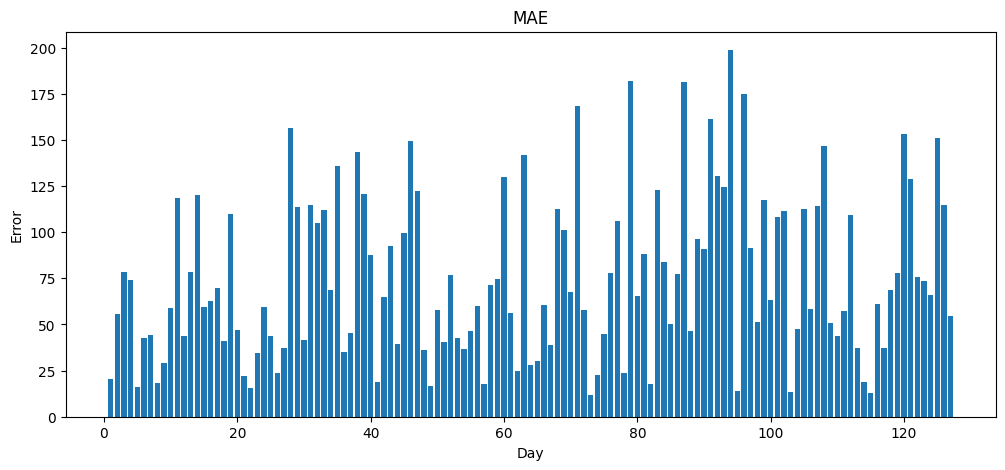

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_POA1)+1), real_loss_POA1)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
def list_r2(y_true, y_pred):
  r2_list=[]
  for day in range(y_true.shape[0]):
    r2_list.append(r2_score(y_true[day,:],y_pred[day,:]))
  return r2_list

In [ ]:
real_r2_POA1=list_r2(yR_POA1_test,predict_POA1_p1)
print(np.mean(real_r2_POA1))

-14.357150608006435


In [ ]:
print(real_r2_POA1)

[0.9719066112599585, -1128.3612436945716, 0.4397289031130446, 0.5192975369838533, 0.9627042663999531, 0.9053696198539496, 0.5490602902959324, 0.9304051053665069, -1.3730734455285765, 0.9202059031152608, 0.8309673721640429, -1.8906797766656092, 0.4307597789996781, -27.33039463606435, -12.25633853949338, 0.387427816543783, 0.7705206504622147, 0.447780900941003, 0.5755446601970464, 0.9068136293084753, 0.9670136646111798, 0.48014580456840206, 0.8781621963081754, 0.6005727343418603, 0.8747478275680233, 0.9757239197610695, -18.681858372273346, 0.3247285811793389, -2.1447950342300652, 0.5587694186533285, 0.4023757884834912, -3.5010955877118235, -3.4385945627088956, 0.46132913555763333, -12.75977762818064, 0.6456871273798255, 0.6639856087982356, -9.626500591644524, -436.1901414144619, 0.2684667484639117, 0.9493454007561278, -1.8169866066029146, -1.8287420896217226, 0.8829347705314086, 0.3162454703450388, -4.6456363381409735, -0.5992135886847654, 0.8304285531696932, 0.9855002141952843, 0.248064

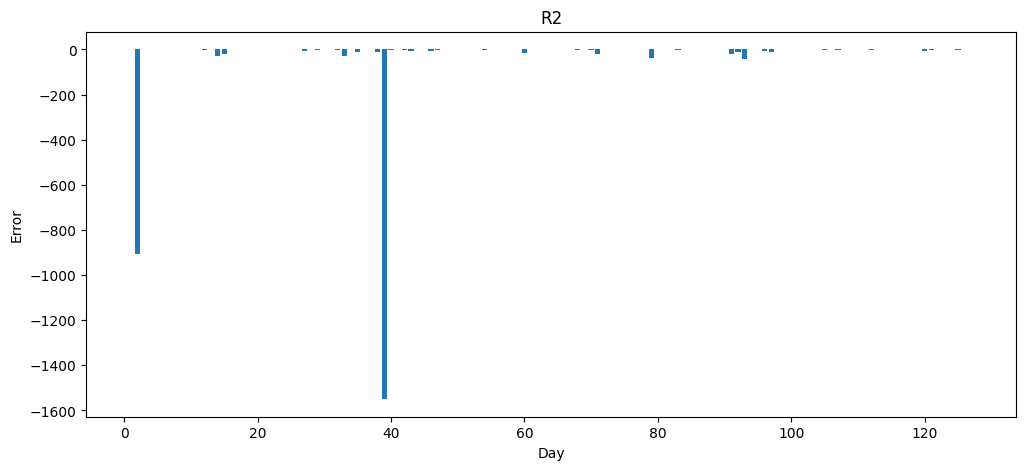

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_POA1)+1), real_r2_POA1)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

In [ ]:
def mape_mod(y_true, y_pred):
  mape_list=[]

  for day in range(y_true.shape[0]):
    y_pred2=[]
    y_true2=[]
    for i in range(0,96):
      if y_true[day,i]>=5 and y_pred[day,i]>=2:
        y_true2.append(y_true[day,i])
        y_pred2.append(y_pred[day,i])
    mape_list.append(np.mean(np.abs((np.array(y_true2) - np.array(y_pred2)) / np.array(y_true2))))
  return mape_list

In [ ]:
real_mape_poa1=mape_mod(yR_POA1_test,predict_POA1_p1)
print(np.mean(real_mape_poa1))

1.4355930725502122


In [ ]:
print(real_mape_poa1)

[np.float64(0.31666789262576683), np.float64(23.74377242364593), np.float64(1.311597231848639), np.float64(1.0251216424090621), np.float64(0.2687738504641938), np.float64(0.42650063309840425), np.float64(2.6529057039904447), np.float64(0.3077667607060507), np.float64(1.325100142354036), np.float64(0.2993979685169054), np.float64(0.35599315448286295), np.float64(1.4541673375437545), np.float64(0.7519032492802654), np.float64(4.223901915679593), np.float64(4.036239608307216), np.float64(0.593306111487915), np.float64(0.7709903262495241), np.float64(0.5325935568856793), np.float64(0.5556133517172792), np.float64(0.4385153744547043), np.float64(0.220827549412108), np.float64(0.5996963023165206), np.float64(0.317556896862961), np.float64(0.7081853988062949), np.float64(0.3823199643187247), np.float64(0.23071663566497486), np.float64(5.151221741990146), np.float64(0.6210702352989862), np.float64(2.424185948546521), np.float64(0.4103311394877309), np.float64(0.5804275715579011), np.float64(2.

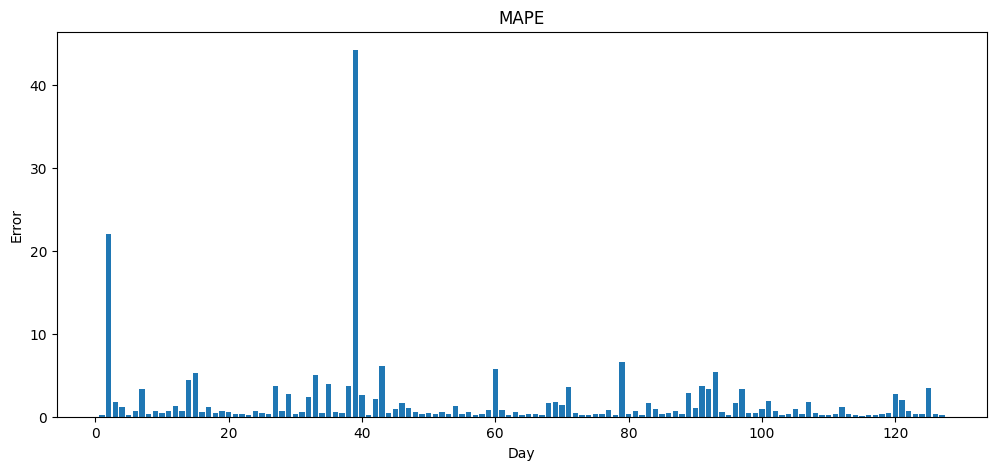

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_poa1)+1), real_mape_poa1)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

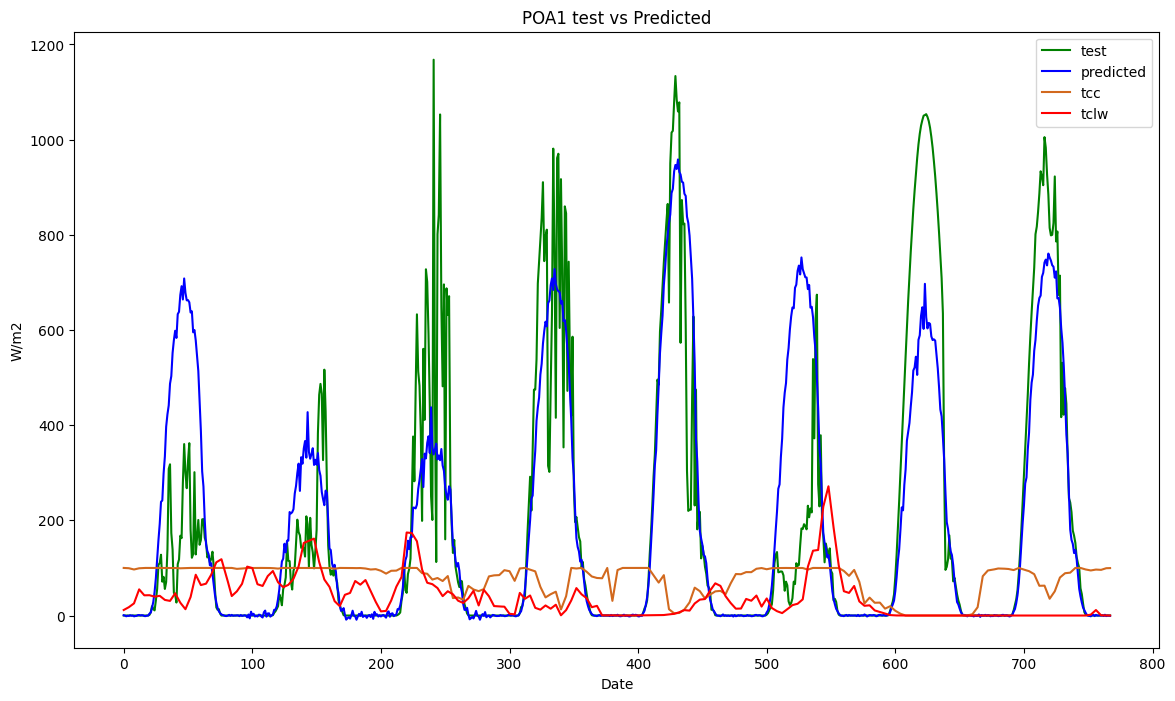

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_POA1_test.shape[0]*yR_POA1_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_POA1_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_POA1_p1.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*300,label='tclw',color='red')
plt.title("POA1 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Model summary

In [ ]:
model1_POA1_GRU4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 384, 128)       │        53,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        12,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,728 (709.88 KB)

 Trainable params: 181,728 (709.88 KB)

 Non-trainable params: 0 (0.00 B)

In case you need to retrain a model based on the results of keras tuner

In [ ]:
X1_POA1_train=np.concatenate((X1_POA1_train,X1_POA1_val),axis=0)
y1_POA1_train=np.concatenate((y1_POA1_train,y1_POA1_val),axis=0)

print(X1_POA1_train.shape)
print(y1_POA1_train.shape)

(1141, 384, 10)
(1141, 96)


In [ ]:
def create_model_poa(X,y,epochs,learning_rate1,cb):
  model1_trial=keras.models.Sequential()
  model1_trial.add(keras.layers.GRU(128,return_sequences=True,activation='tanh',input_shape=((obs_window),(5+n_exo_var))))
  model1_trial.add(keras.layers.Dropout(0.1))
  model1_trial.add(keras.layers.GRU(128,return_sequences=False))
  model1_trial.add(keras.layers.Dropout(0.3))
  model1_trial.add(keras.layers.Dense(64,activation='relu'))
  model1_trial.add(keras.layers.Dense(win_size))


  model1_trial.compile(optimizer=Adam(learning_rate=learning_rate1),loss='mae',metrics=['mae','mse','mape'])
  model1_trial.fit(X,y,epochs=epochs,callbacks=[cb])
  return model1_trial

In [ ]:
model1_POA1_GRU4_v2=create_model_poa(X1_POA1_train,y1_POA1_train,70,0.005,check_point_poa1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.1104 - mae: 0.1104 - mape: 246.6687 - mse: 0.0341
Epoch 2/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0626 - mae: 0.0626 - mape: 85.9225 - mse: 0.0135
Epoch 3/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0594 - mae: 0.0594 - mape: 68.4046 - mse: 0.0131
Epoch 4/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0585 - mae: 0.0585 - mape: 63.7774 - mse: 0.0130
Epoch 5/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0575 - mae: 0.0575 - mape: 57.9151 - mse: 0.0129
Epoch 6/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0565 - mae: 0.0565 - mape: 53.5994 - mse: 0.0127
Epoch 7/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0563 - mae: 0.0563 - mape: 50.6576 - mse: 0.0129
Epoch 8/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0556 - mae: 0.0556 - mape: 48.3648 - mse: 0.0126
Epoch 9/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0553 - mae: 0.0553 - mape: 46.1945 - mse: 0.0127
Epoch 10/

In [ ]:
model1_POA1_GRU4_v2=load_model("model_checkpoint/best_model_poa1.keras")

Save the model

In [ ]:
model1_POA1_GRU4_v2.save('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_POA1_n5_v2.keras')

Load model

In [ ]:
model1_POA1_GRU4_v2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_POA1_n5_v2.keras')

Prediction and evaluation

In [ ]:

pred_POA1_p1_v2=model1_POA1_GRU4_v2.predict(X1_POA1_test)
predict_POA1_p1_v2=(scaler_POA1.inverse_transform(pred_POA1_p1_v2.reshape(-1,1))).reshape(pred_POA1_p1_v2.shape[0],pred_POA1_p1_v2.shape[1])


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step


MAE

In [ ]:
real_loss_POA1_v2=list_mae(yR_POA1_test,predict_POA1_p1_v2)
print(np.mean(real_loss_POA1_v2))

75.21494700804614


In [ ]:
print(real_loss_POA1_v2)

[38.036484269620495, 59.44493183597202, 91.8871767817033, 72.7817025998031, 28.483022528666435, 40.13961919788948, 34.72007892612367, 89.7916949943882, 16.894505537717293, 118.38018385174297, 113.90014262249512, 21.398764671969545, 106.4472027924058, 96.8638925577917, 46.243854915138684, 117.58973722673811, 96.90621760673078, 115.68576427598737, 99.65195866323609, 42.07969032553603, 28.75353528231176, 22.208042044971133, 50.61583604431132, 58.47540014105372, 80.21579683153425, 29.136861910698176, 48.94421972110327, 138.87404587056827, 128.96053802357773, 62.28392993460761, 113.22923041392137, 164.1885721932094, 38.005162909265756, 97.20427566272991, 168.49632635413238, 23.528209757734192, 134.33534791210354, 128.69244514701202, 58.00418394519411, 45.17836949215675, 11.333696148019703, 37.715700749137646, 43.29934092828855, 40.45329847621615, 82.0666608976339, 163.25270071558907, 97.97982159492024, 50.55438056243421, 40.94753653052009, 171.0116316829051, 19.56502213136235, 63.0069710093

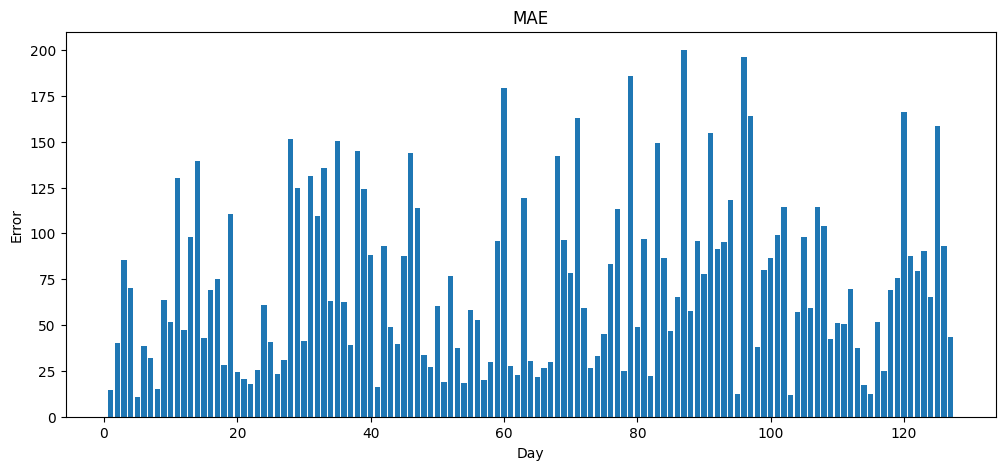

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_POA1_v2)+1), real_loss_POA1_v2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_POA1_v2=list_r2(yR_POA1_test,predict_POA1_p1_v2)
print(np.mean(real_r2_POA1_v2))

-11.63505508931502


In [ ]:
print(real_r2_POA1_v2)

[0.9222382018307929, -967.4009972180086, 0.42485376825375565, 0.5052744137104676, 0.9691098339048508, 0.8413976062412962, 0.5822930416132197, 0.5510638896176632, 0.8214732053288095, 0.38274889305045323, 0.3822128226073559, 0.6730025751191815, 0.39742227870203595, -18.439760472592006, -10.002908918111565, 0.35555339574346145, 0.2609508462527048, 0.36519075468133533, 0.43367986919873835, 0.9226090409694294, 0.957263628135588, 0.6782001016058017, 0.9128782057283368, 0.6218986691941668, 0.6804875730088067, 0.9569548092721569, -15.519076650363274, 0.2941260589393131, -3.0303740184873478, 0.5216945658855683, 0.3602019221054378, -7.243557501538678, -2.440500459554614, 0.42397380140183316, -17.572988281935423, 0.7299771342057008, 0.30087550152559606, -8.185596072943147, -372.5910460907288, 0.3980305927353457, 0.9967487971001886, 0.23485620407180308, -1.1542943423183996, 0.8885491747949308, 0.5037239217368605, -6.314722555264053, -0.4753857281231808, 0.9032399373857929, 0.9378779260558963, 0.20

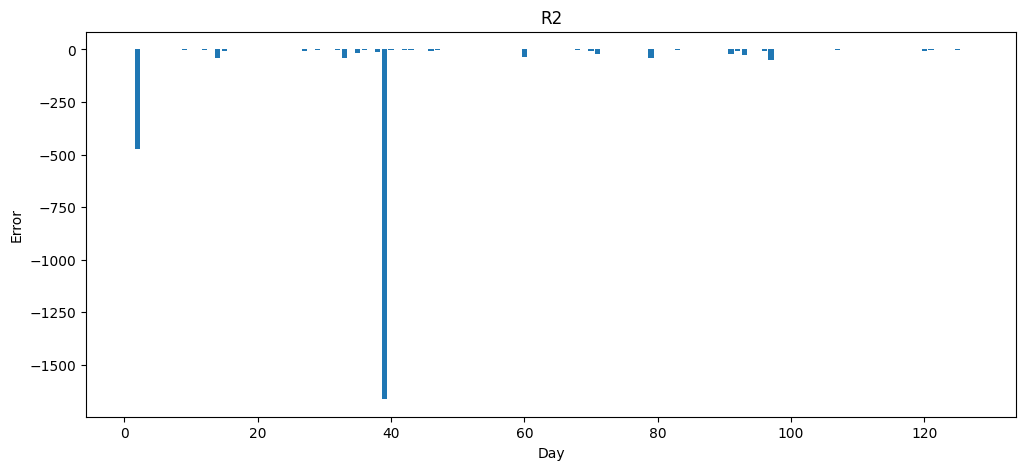

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_POA1_v2)+1), real_r2_POA1_v2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Mape

In [ ]:
real_mape_poa1_v2=mape_mod(yR_POA1_test,predict_POA1_p1_v2)
print(np.mean(real_mape_poa1_v2))

1.3389189481275883


In [ ]:
print(real_mape_poa1_v2)

[np.float64(0.5072922342007772), np.float64(23.014921405565172), np.float64(1.2401813253942808), np.float64(1.1530157132655703), np.float64(0.4911290182261861), np.float64(0.6094703936649933), np.float64(2.3949815491970203), np.float64(0.5250550733392785), np.float64(0.4155000686205349), np.float64(0.6043963082894244), np.float64(0.6102964026355037), np.float64(0.7348530397595064), np.float64(0.7458815907500598), np.float64(3.6001541844982006), np.float64(4.231257722550154), np.float64(0.5977511107832363), np.float64(1.6310760543071487), np.float64(0.6493747995556998), np.float64(0.6075042692374693), np.float64(0.4777820954066087), np.float64(0.2669308103925167), np.float64(0.5196927639778883), np.float64(0.300681527863607), np.float64(0.7038871133836816), np.float64(0.4520330618515743), np.float64(0.2546869054406936), np.float64(5.132945586574867), np.float64(0.6397435713154265), np.float64(3.3613163772947408), np.float64(0.41002263687437274), np.float64(0.5846400753675), np.float64(3

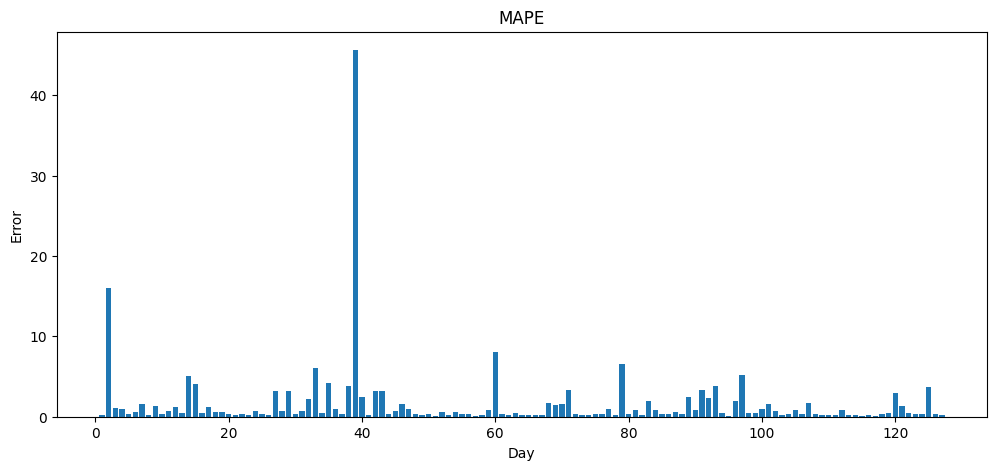

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_poa1_v2)+1), real_mape_poa1_v2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Model summary

In [ ]:
model1_POA1_GRU4_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 384, 128)       │        53,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 384, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 96)             │        12,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,186 (2.08 MB)

 Trainable params: 181,728 (709.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 363,458 (1.39 MB)

Check the graphs to understand atypical errors

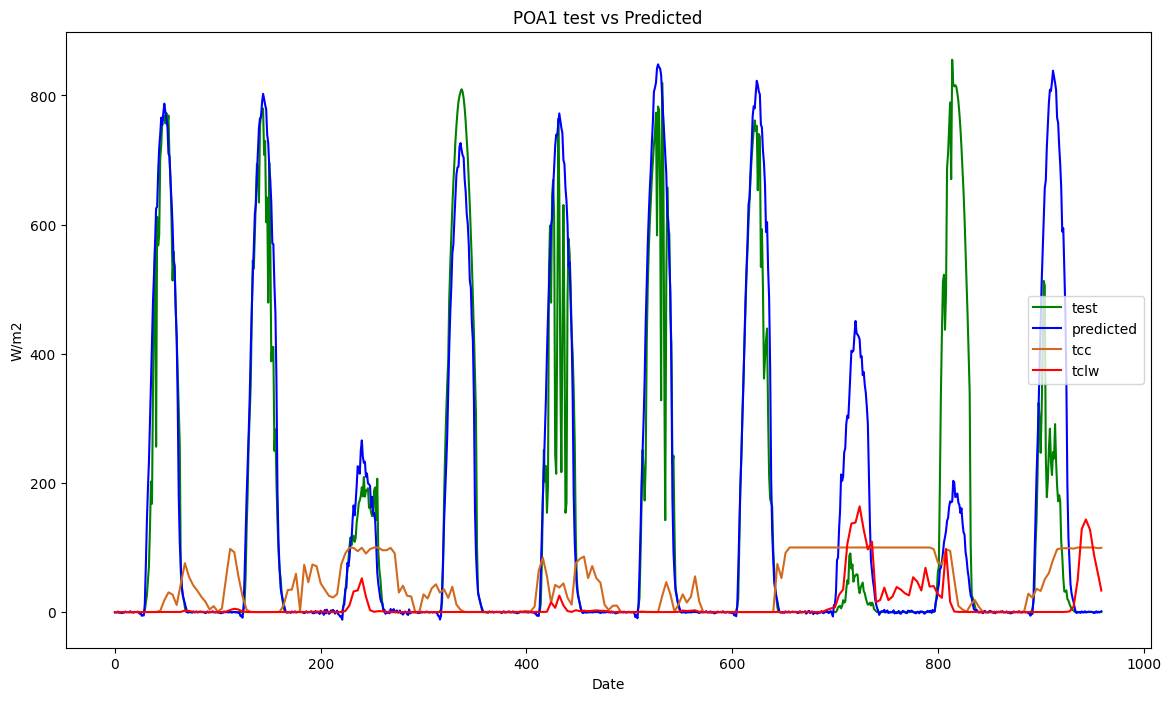

In [ ]:
plt.figure(figsize=(14,8))
st_day=20
end_day=30
dat_clouds=yR_POA1_test.shape[0]*yR_POA1_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_POA1_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_POA1_p1_v2.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*300,label='tclw',color='red')
plt.title("POA1 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

GRU for POA2

Define callbacks

In [ ]:
check_point_poa2=ModelCheckpoint(filepath="model_checkpoint/best_model_poa2.keras",monitor='mae',save_best_only=True)

Define object tuner

In [ ]:
tuner_POA2=BayesianOptimization(create_model_tun_poa,objective='val_loss',max_trials=90,num_initial_points=18,alpha=1e-4,beta=2.6,project_name='gru2_tun_d2')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
tuner_POA2.search(X1_POA2_train,y1_POA2_train,epochs=40,validation_data=(X1_POA2_val,y1_POA2_val),callbacks=[early_stop1])
tuner_POA2.results_summary()

Trial 90 Complete [00h 00m 36s]
val_loss: 0.04010957479476929

Best val_loss So Far: 0.038646746426820755
Total elapsed time: 00h 53m 58s
Results summary
Results in ./gru2_tun_d2
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 64 summary
Hyperparameters:
units1: 128
drop1: 0.1
units2: 128
drop2: 0.3
units3: 64
lr: 0.005
Score: 0.038646746426820755

Trial 80 summary
Hyperparameters:
units1: 128
drop1: 0.1
units2: 128
drop2: 0.2
units3: 96
lr: 0.005
Score: 0.03884292393922806

Trial 78 summary
Hyperparameters:
units1: 64
drop1: 0.2
units2: 64
drop2: 0.2
units3: 128
lr: 0.005
Score: 0.03886761888861656

Trial 01 summary
Hyperparameters:
units1: 64
drop1: 0.2
units2: 32
drop2: 0.1
units3: 128
lr: 0.005
Score: 0.03898891061544418

Trial 03 summary
Hyperparameters:
units1: 64
drop1: 0.1
units2: 32
drop2: 0.3
units3: 64
lr: 0.005
Score: 0.03901872783899307

Trial 68 summary
Hyperparameters:
units1: 64
drop1: 0.1
units2: 32
drop2: 0.2
units3: 128
lr: 0.005
Score: 0.03

Define the best model

In [ ]:
model1_POA2_GRU4=tuner_POA2.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model1_POA2_GRU4.save('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_POA2_n5.keras')

In [ ]:
model1_POA2_GRU4=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_POA2_n5.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediction and evaluation

In [ ]:

pred_POA2_p1=model1_POA2_GRU4.predict(X1_POA2_test)
predict_POA2_p1=(scaler_POA2.inverse_transform(pred_POA2_p1.reshape(-1,1))).reshape(pred_POA2_p1.shape[0],pred_POA2_p1.shape[1])

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


MAE

In [ ]:
real_loss_POA2=list_mae(yR_POA2_test,predict_POA2_p1)
print(np.mean(real_loss_POA2))

70.58197244301437


In [ ]:
print(real_loss_POA2)

[23.161488714765497, 56.00980530602084, 88.16789707737144, 73.97504533745524, 19.061500093166444, 36.62381790278732, 34.28814805623609, 24.90957251373685, 94.05225708582394, 27.599485695203303, 48.04517277995904, 78.63967276892808, 104.44290461149258, 124.77074683748333, 43.87653220122917, 84.30755232525458, 54.98319587068844, 89.67878674245823, 85.56908533392748, 39.82065248140617, 27.60043157820086, 23.251728149962556, 49.8619296308587, 62.883392747589255, 42.34304257340486, 24.609515651748342, 46.566639643312506, 134.14968636612195, 107.05332289204205, 59.28561302468527, 110.16531841077648, 114.7970831452136, 36.011707538812175, 96.85943363668106, 135.0887589184366, 18.063827964665077, 73.99248237223246, 127.60630564250852, 56.18206431372917, 47.83749958925685, 33.717358925893954, 64.71629830980332, 42.27884815564784, 44.140820676862525, 92.6228301076906, 133.7626479603379, 98.79257529477336, 62.63634534032457, 22.761591861050487, 164.9745481707514, 31.13656989399347, 61.89517769782

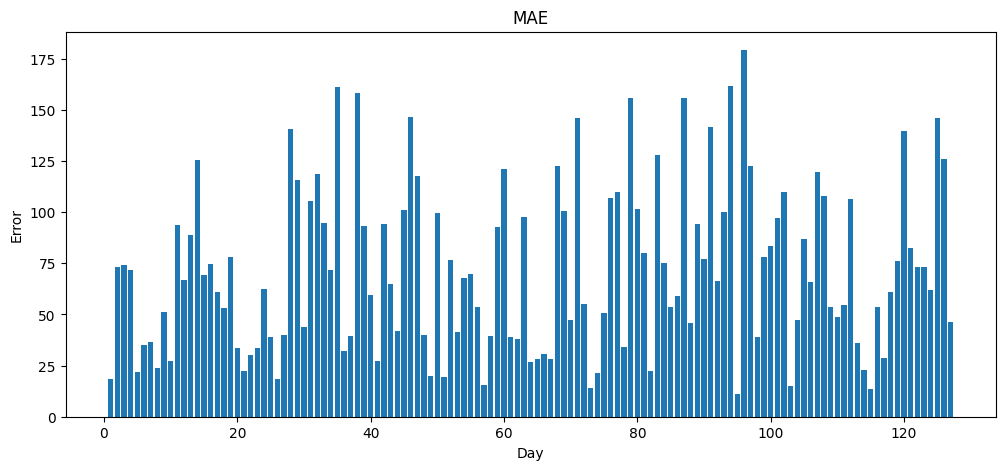

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_POA2)+1), real_loss_POA2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_POA2=list_r2(yR_POA2_test,predict_POA2_p1)
print(np.mean(real_r2_POA2))

-149.1923988577466


In [ ]:
print(real_r2_POA2)

[0.961307165537516, -3486.3363264592394, 0.46811330911975213, 0.47603726515473854, 0.9757372574096288, 0.862140407913416, 0.5460342996803573, 0.9543297386601856, -3.883673298719893, 0.9635525763298869, 0.8878185038046237, -4.249819441528965, 0.37903393774962446, -40.96083081214168, -12.023017013484885, 0.6798425190436981, 0.706217178543772, 0.6280879657248439, 0.570850992458354, 0.9262744131200004, 0.9641519275309955, 0.52186179027871, 0.9122169931721626, 0.6009879935119584, 0.8978263850061023, 0.9715834151101912, -19.045759185211974, 0.2859032633781887, -2.325544794802626, 0.5133328656871168, 0.34732975241049924, -4.148776128582422, -3.000117624869148, 0.3969267099054309, -14.194257261883209, 0.791318951209049, 0.748134971084081, -10.42153696126895, -15240.931830644808, 0.3106869856104043, 0.9609344840555873, -1.8758602446693922, -1.7074322282491639, 0.8969530636033702, 0.26285483705344914, -5.426630179969632, -0.8147027357163836, 0.8225781201918506, 0.9852567317107631, 0.200115437144

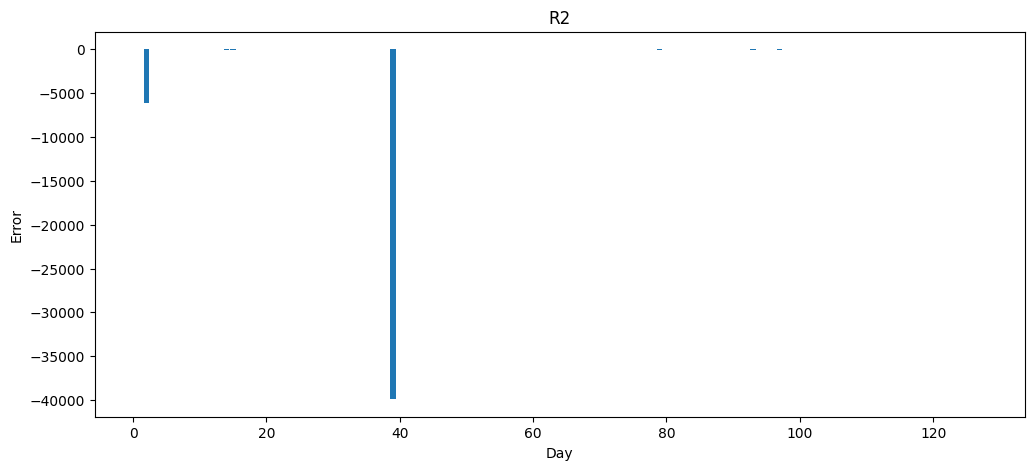

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_POA2)+1), real_r2_POA2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_poa2=mape_mod(yR_POA2_test,predict_POA2_p1)
print(np.mean(real_mape_poa2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_poa2)

[np.float64(0.28804114163962186), np.float64(20.926152073868455), np.float64(4.330037431430138), np.float64(1.0621399121356854), np.float64(0.198018497490021), np.float64(0.5017188188205359), np.float64(3.7866297286865), np.float64(0.2953903179029814), np.float64(2.120677055278431), np.float64(0.22516010101445452), np.float64(0.3083848438461184), np.float64(2.15333108331659), np.float64(0.6373985980562826), np.float64(5.407097293923563), np.float64(3.779779716223852), np.float64(0.559495703337133), np.float64(0.86613699466813), np.float64(0.6097237468190995), np.float64(0.5677768575464848), np.float64(0.4561478748207098), np.float64(0.2595886576290855), np.float64(0.5407768514888748), np.float64(0.3137791756178805), np.float64(0.7789370416399363), np.float64(0.3945516430802675), np.float64(0.2365971240200598), np.float64(5.972649556507354), np.float64(0.5958766431087493), np.float64(2.3983922250268015), np.float64(0.417709628071253), np.float64(0.5422545861737573), np.float64(2.6727910

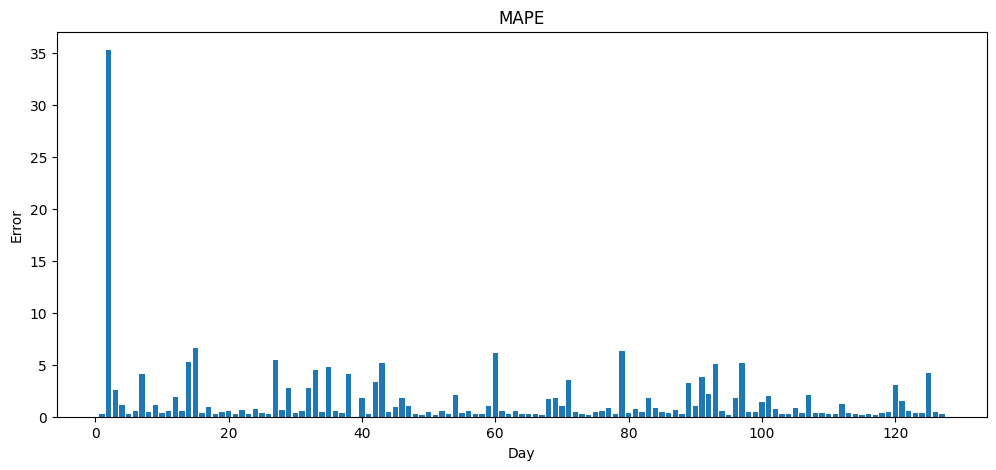

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_poa2)+1), real_mape_poa2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

In [ ]:
model1_POA2_GRU4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 384, 128)       │        53,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │         6,240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,328 (653.62 KB)

 Trainable params: 167,328 (653.62 KB)

 Non-trainable params: 0 (0.00 B)

Check the graphs to understand atypical errors

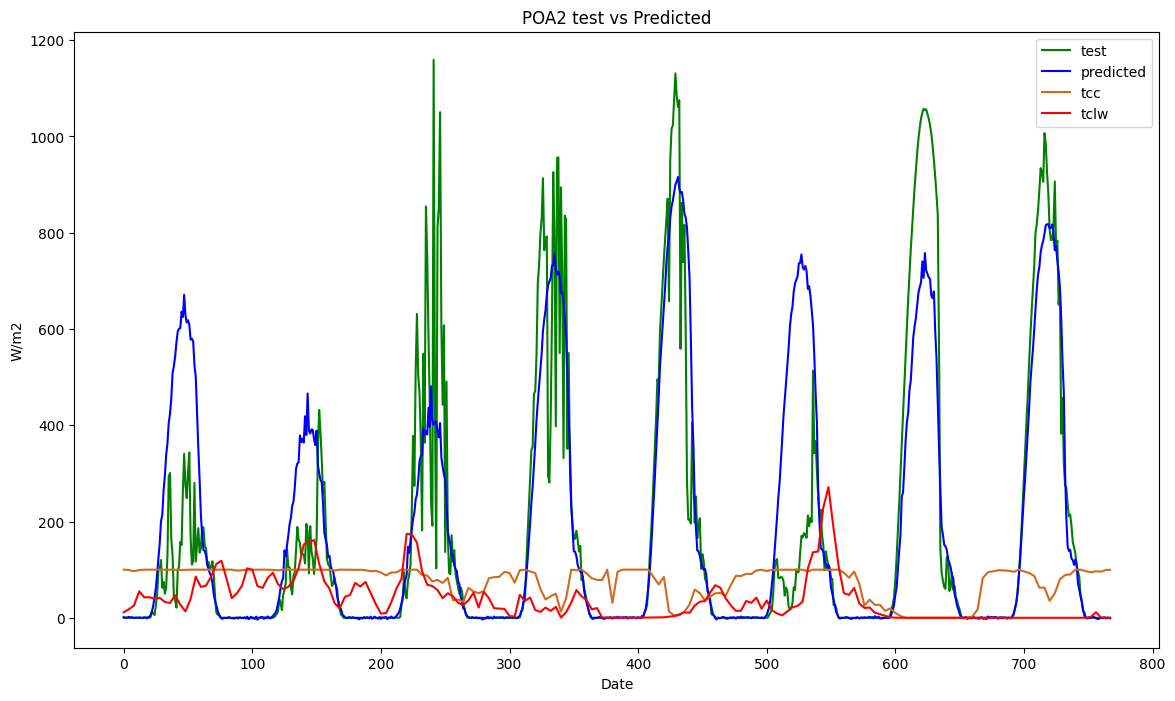

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_POA2_test.shape[0]*yR_POA2_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_POA2_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_POA2_p1.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*300,label='tclw',color='red')
plt.title("POA2 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Retraining in case you need it

In [ ]:
X1_POA2_train=np.concatenate((X1_POA2_train,X1_POA2_val),axis=0)
y1_POA2_train=np.concatenate((y1_POA2_train,y1_POA2_val),axis=0)

print(X1_POA2_train.shape)
print(y1_POA2_train.shape)

(1141, 384, 10)
(1141, 96)


In [ ]:
model1_POA2_GRU4_v2=create_model_poa(X1_POA2_train,y1_POA2_train,70,0.005,check_point_poa2)

Epoch 1/70


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.1140 - mae: 0.1140 - mape: 243.5555 - mse: 0.0376
Epoch 2/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0627 - mae: 0.0627 - mape: 89.6214 - mse: 0.0139
Epoch 3/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0588 - mae: 0.0588 - mape: 70.1339 - mse: 0.0131
Epoch 4/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0575 - mae: 0.0575 - mape: 61.9044 - mse: 0.0132
Epoch 5/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0561 - mae: 0.0561 - mape: 55.9417 - mse: 0.0130
Epoch 6/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0556 - mae: 0.0556 - mape: 52.1446 - mse: 0.0131
Epoch 7/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0554 - mae: 0.0554 - mape: 50.3273 - mse: 0.0130
Epoch 8/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0545 - mae: 0.0545 - mape: 48.3837 - mse: 0.0128
Epoch 9/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0549 - mae: 0.0549 - mape: 46.8953 - mse: 0.0130
Epoch 10/70
36/36 ━━

In [ ]:
model1_POA2_GRU4_v2=load_model("model_checkpoint/best_model_poa2.keras")

Save the model

In [ ]:
model1_POA2_GRU4_v2.save('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_POA2_n5_v2.keras')

In [ ]:
model1_POA2_GRU4_v2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_POA2_n5_v2.keras')

Prediction and evaluation

In [ ]:
pred_POA2_p1_v2=model1_POA2_GRU4_v2.predict(X1_POA2_test)
predict_POA2_p1_v2=(scaler_POA2.inverse_transform(pred_POA2_p1_v2.reshape(-1,1))).reshape(pred_POA2_p1_v2.shape[0],pred_POA2_p1_v2.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


MAE

In [ ]:
real_loss_POA2_v2=list_mae(yR_POA2_test,predict_POA2_p1_v2)
print(np.mean(real_loss_POA2_v2))

69.34064183821133


In [ ]:
print(real_loss_POA2_v2)

[20.167243462863976, 53.19413346000736, 83.39018272739894, 74.4177709589592, 20.47682113020462, 37.31172541540443, 33.82775424881972, 68.95416654782441, 16.534992391827473, 81.50417996518631, 116.67895952475483, 26.20362061578055, 106.80360150231841, 121.79393780708263, 41.0608603552157, 127.1199259915705, 63.32390708014242, 117.5893321272654, 101.65651315538497, 38.20707446243393, 21.561142809354394, 18.24113571863174, 80.88575419224811, 61.38065710881883, 70.80059207132005, 21.041069886424854, 43.75096779729903, 136.29718889672074, 117.09610278847947, 61.390935616902794, 112.43108634802462, 119.06981905395305, 33.38174943100175, 98.99021609711112, 139.69498077269648, 18.21084028349357, 126.5858804288007, 138.7894724551579, 53.36639246771569, 46.11621772824844, 27.332017055912853, 33.23302583602663, 39.51717683630101, 53.584220694829504, 101.57346792302872, 141.6837237468018, 93.1909924337665, 71.01370738320888, 13.991437285241494, 167.4151424274933, 23.997114931608365, 64.25760251318

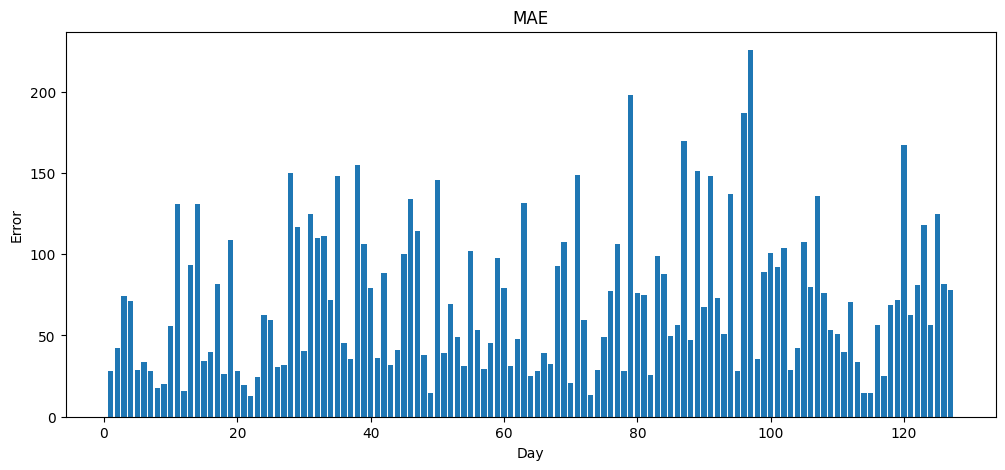

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_POA2_v2)+1), real_loss_POA2_v2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_POA2_v2=list_r2(yR_POA2_test,predict_POA2_p1_v2)
print(np.mean(real_r2_POA2_v2))

-131.94646706584825


In [ ]:
print(real_r2_POA2_v2)

[0.9671421453230253, -3091.4892511082985, 0.35308535168001287, 0.4781879578064102, 0.9765858963195633, 0.8658274256789198, 0.5446212361520969, 0.742297233226979, 0.7784675331080618, 0.7048866259093041, 0.3235772292074339, 0.41467792046169405, 0.3452395802047348, -39.72167775928052, -10.14548894715873, 0.284776828810138, 0.6163648779314863, 0.3115230064073018, 0.3806885805586232, 0.9244285236435456, 0.9753395896021122, 0.7195413519411147, 0.7659049195550743, 0.6102567433987265, 0.728182545702354, 0.9759178012279075, -16.4917456736578, 0.25688993207288635, -2.791068518279102, 0.48702923383696595, 0.3142596633251479, -4.51733269867212, -2.3276550055983583, 0.3650340608474012, -14.562177812151301, 0.8113907863589044, 0.2767496465354842, -12.023308813225864, -13527.02023429049, 0.3392632634666065, 0.9771512507973391, 0.34416651067949255, -1.3177312210388612, 0.842744628173213, 0.11256189239912406, -6.274985742665805, -0.6815412307281585, 0.7707028939355236, 0.9913715804238374, 0.17243882043

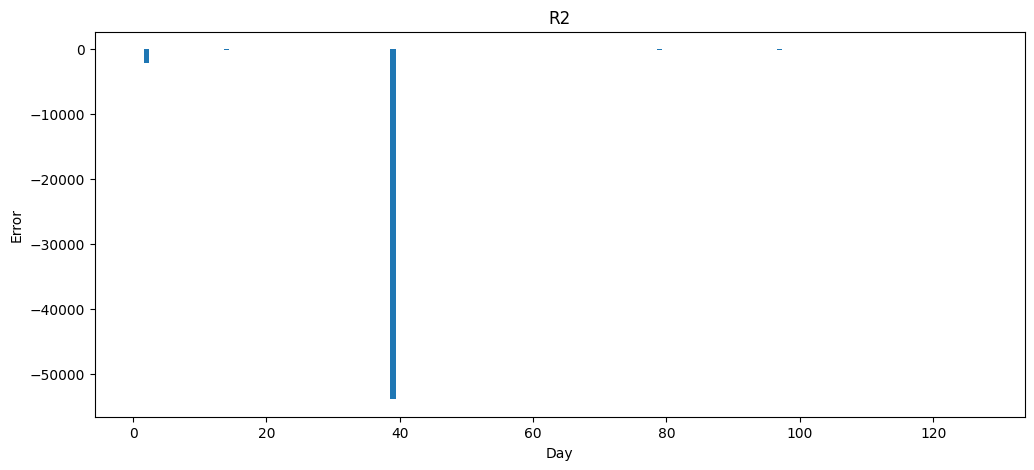

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_POA2_v2)+1), real_r2_POA2_v2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_poa2_v2=mape_mod(yR_POA2_test,predict_POA2_p1_v2)
print(np.mean(real_mape_poa2_v2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_poa2_v2)

[np.float64(0.37276488150936715), np.float64(20.817264193012363), np.float64(1.7931994651628524), np.float64(1.162809970937966), np.float64(0.4097357274748954), np.float64(0.5665279273033653), np.float64(3.7813441289260488), np.float64(0.4484316276760337), np.float64(0.4491525702717721), np.float64(0.4283517324880419), np.float64(0.6064578026774936), np.float64(0.8833782390969754), np.float64(0.6908339819801195), np.float64(5.139257369827151), np.float64(3.6531435673862163), np.float64(0.6228776193073456), np.float64(1.0744487703190462), np.float64(0.5864544858883671), np.float64(0.6155398103790527), np.float64(0.49384013131028376), np.float64(0.23077317062833796), np.float64(0.4526042996751173), np.float64(0.4413790688844356), np.float64(0.7856897696983091), np.float64(0.4033866704590616), np.float64(0.2608237747409702), np.float64(5.84501392337606), np.float64(0.6123076403581843), np.float64(2.8875874411956217), np.float64(0.43683068134628966), np.float64(0.5485603768715751), np.floa

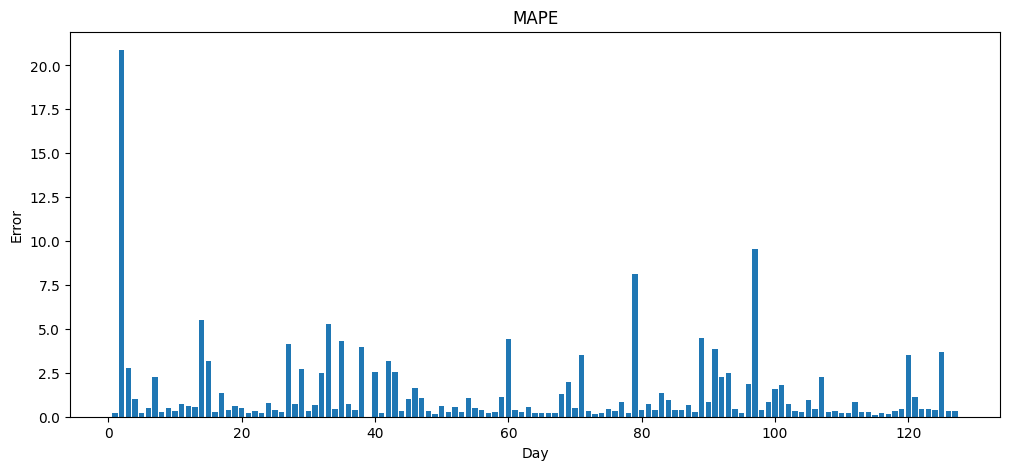

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_poa2_v2)+1), real_mape_poa2_v2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

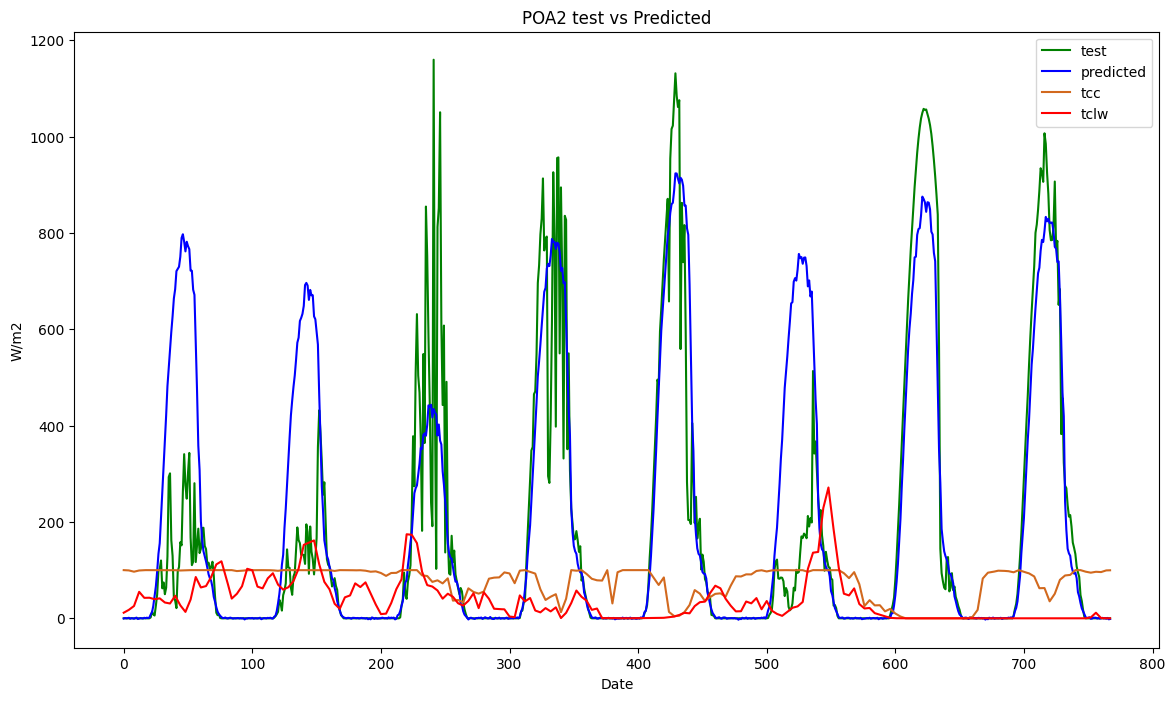

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_POA2_test.shape[0]*yR_POA2_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_POA2_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_POA2_p1_v2.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*300,label='tclw',color='red')
plt.title("POA2 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Model summary

In [ ]:
model1_POA2_GRU4_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 384, 128)       │        53,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 384, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 96)             │         6,240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501,986 (1.91 MB)

 Trainable params: 167,328 (653.62 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 334,658 (1.28 MB)

Visualize Prediction vs Real data

Create model for retraining Rear side

In [ ]:
def create_model_tun_rear(hp):
  seq_input=keras.layers.Input(shape=(obs_window,(9+n_exo_var)),name='seq-input')
  xrear=keras.layers.GRU(units=hp.Choice('units1',[64,128]),return_sequences=True,
                                     activation='tanh')(seq_input)
  xrear=keras.layers.Dropout(hp.Choice('drop1',[0.1,0.2,0.3]))(xrear)
  xrear=keras.layers.GRU(units=hp.Choice('units2',[32,64,128]),return_sequences=False)(xrear)
  xrear=keras.layers.Dropout(hp.Choice('drop2',[0.1,0.2,0.3]))(xrear)
  xrear=keras.layers.Dense(units=hp.Choice('units3',[64,96,128]),activation='relu')(xrear)

  surf_input=keras.layers.Input(shape=(4,),name='surf-input')
  s=keras.layers.Dense(32,activation='relu')(surf_input)

  comb=Concatenate()([xrear,s])
  comb=keras.layers.Dense(win_size,activation='relu')(comb)
  output=keras.layers.Dense(win_size,activation='linear',name="Irr_output")(comb)

  model1_trial=keras.models.Model(inputs=[seq_input,surf_input],outputs=output)

  model1_trial.compile(optimizer=Adam(learning_rate=hp.Choice('lr',[1e-3,5e-4,5e-3])),loss='mae',metrics=['mae','mse','mape'])

  return model1_trial

In [ ]:
def create_model_rear(X,y,epochs,learning_rate1,cb):
  seq_input=keras.layers.Input(shape=(obs_window,(9+n_exo_var)),name='seq-input')
  xrear=keras.layers.GRU(64,return_sequences=True,activation='tanh')(seq_input)
  xrear=keras.layers.Dropout(0.2)(xrear)
  xrear=keras.layers.GRU(64,return_sequences=False)(xrear)
  xrear=keras.layers.Dropout(0.3)(xrear)
  xrear=keras.layers.Dense(128,activation='relu')(xrear)

  surf_input=keras.layers.Input(shape=(4,),name='surf-input')
  s=keras.layers.Dense(32,activation='relu')(surf_input)

  comb=Concatenate()([xrear,s])
  comb=keras.layers.Dense(win_size,activation='relu')(comb)
  output=keras.layers.Dense(win_size,activation='linear',name="Irr_output")(comb)

  model1_trial=keras.models.Model(inputs=[seq_input,surf_input],outputs=output)

  model1_trial.compile(optimizer=Adam(learning_rate=learning_rate1),loss='mae',metrics=['mae','mse','mape'])
  model1_trial.fit(X,y,epochs=epochs,callbacks=[cb])
  return model1_trial

LSTM for REAR 1

Define callbacks

In [ ]:
check_point_rear1=ModelCheckpoint(filepath="model_checkpoint/best_model_rear1.keras",monitor='mae',save_best_only=True)

Define object tuner

In [ ]:
tuner_Rear1=BayesianOptimization(create_model_tun_rear,objective='val_loss',max_trials=90,num_initial_points=18,alpha=1e-4,beta=2.6,project_name='gru2_tunv4_d3')

In [ ]:
tuner_Rear1.search([X1_Rear1_train,surf_Rear1_train],y1_Rear1_train,epochs=40,validation_data=([X1_Rear1_val,surf_Rear1_val],y1_Rear1_val),callbacks=[early_stop1])
tuner_Rear1.results_summary()

Trial 90 Complete [00h 00m 23s]
val_loss: 0.024842990562319756

Best val_loss So Far: 0.024573471397161484
Total elapsed time: 00h 49m 44s
Results summary
Results in ./gru2_tunv4_d3
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 22 summary
Hyperparameters:
units1: 64
drop1: 0.2
units2: 32
drop2: 0.1
units3: 96
lr: 0.001
Score: 0.024573471397161484

Trial 00 summary
Hyperparameters:
units1: 128
drop1: 0.3
units2: 32
drop2: 0.2
units3: 96
lr: 0.0005
Score: 0.024610301479697227

Trial 55 summary
Hyperparameters:
units1: 128
drop1: 0.1
units2: 128
drop2: 0.1
units3: 128
lr: 0.005
Score: 0.024624917656183243

Trial 65 summary
Hyperparameters:
units1: 64
drop1: 0.3
units2: 128
drop2: 0.3
units3: 128
lr: 0.005
Score: 0.024689234793186188

Trial 18 summary
Hyperparameters:
units1: 64
drop1: 0.2
units2: 32
drop2: 0.3
units3: 64
lr: 0.005
Score: 0.02474096417427063

Trial 30 summary
Hyperparameters:
units1: 128
drop1: 0.3
units2: 32
drop2: 0.3
units3: 64
lr: 0.0005
Sco

Define the best model

In [ ]:
model1_Rear1_GRU4=tuner_Rear1.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model1_Rear1_GRU4.save('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_Rear1_n5.keras')

In [ ]:
model1_Rear1_GRU4=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_Rear1_n5.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediction and evaluation

In [ ]:

pred_Rear1_p1=model1_Rear1_GRU4.predict([X1_Rear1_test,surf_Rear1_test])
predict_Rear1_p1=(scaler_Rear1.inverse_transform(pred_Rear1_p1.reshape(-1,1))).reshape(pred_Rear1_p1.shape[0],pred_Rear1_p1.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


MAE

In [ ]:
real_loss_Rear1=list_mae(yR_Rear1_test,predict_Rear1_p1)
print(np.mean(real_loss_Rear1))

7.970299643564975


In [ ]:
print(real_loss_Rear1)

[4.554650732535343, 11.03643907716127, 30.710370694813587, 13.679306790539828, 13.168321023125463, 8.48760348680514, 12.586819099490581, 6.067274516313976, 3.625126116182686, 2.8450447270308925, 5.13934519413657, 5.593677339165343, 12.195414909153003, 9.114862303780967, 4.159532632765104, 43.53539834693252, 14.272779750631512, 18.097020553020105, 16.67962793387394, 10.438036466795555, 8.32089023856575, 2.3367373178302064, 4.608389162665833, 5.011625757480313, 3.685569892498375, 2.318335169310006, 3.5829948785181718, 13.868539231530967, 8.342467314072131, 6.295955831777476, 11.309109869511394, 8.762885063971433, 6.245865413230578, 10.068841044418798, 12.370565636712058, 2.494551190395032, 5.307096792272541, 11.50828311296833, 7.53415855201753, 3.725708987402541, 2.98555657999208, 6.366086747539268, 3.9543370790189862, 4.5602359665230505, 8.208797447332811, 11.319957865025271, 9.021972227631181, 4.026446559435186, 2.7808822506723367, 12.422647514625032, 2.915007684579047, 7.4805604921121

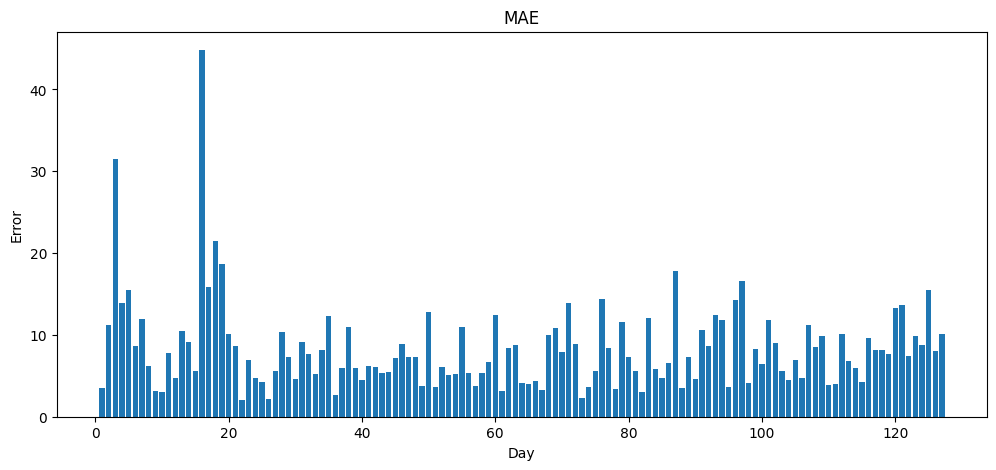

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_Rear1)+1), real_loss_Rear1)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_Rear1=list_r2(yR_Rear1_test,predict_Rear1_p1)
print(np.mean(real_r2_Rear1))

-2.6745321185446014


In [ ]:
print(real_r2_Rear1)

[0.8350027648587088, 0.32643010735827027, 0.08178595395418153, 0.509886212420261, 0.6865214937704422, 0.7753321631434246, 0.2781085721785608, 0.8728979803224549, 0.4640056180069049, 0.951246329256089, 0.8423842940632837, -0.6752366505609824, 0.1733341414804268, -27.895817889979966, -22.313441245866464, -0.016144796810037887, 0.6280694857303029, 0.44479674177332895, 0.3940272528078883, 0.7014106572513439, 0.771289186249659, 0.8731912534768907, 0.9101707847100248, 0.7405416343981445, 0.8954668482432718, 0.9678141735837037, -29.663079404411274, -0.01657310821890645, -0.5815201127946545, 0.46746303604607176, 0.20957819592246163, -2.012760834101975, -26.871749169300355, 0.242335905217973, -9.483155614352516, 0.6867901933173814, 0.8524165923883074, -5.866492492552676, 0.3629335331350244, 0.31630229521902153, 0.9643422611104108, -1.1796264915607164, -1.9543483635343901, 0.830610548115069, 0.279381974658948, -2.7615772858936767, -0.14960199523635542, 0.9333788995100221, 0.9675921731953447, 0.4

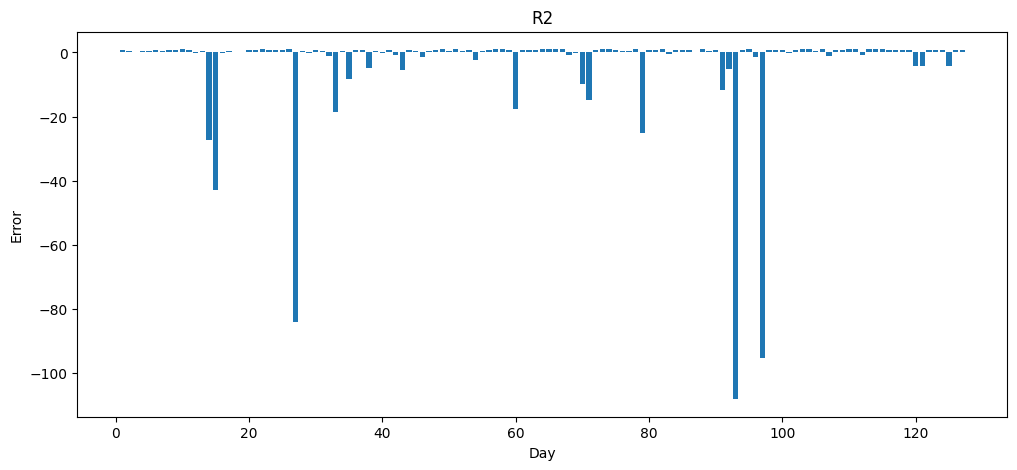

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_Rear1)+1),real_r2_Rear1)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_Rear1=mape_mod(yR_Rear1_test,predict_Rear1_p1)
print(np.mean(real_mape_Rear1))

0.8641318467561988


In [ ]:
print(real_mape_Rear1)

[np.float64(0.375072963636022), np.float64(0.5556670884129207), np.float64(0.8269834674611355), np.float64(0.4361693571388507), np.float64(0.5051824943294773), np.float64(0.39068039784895314), np.float64(0.6826643685123716), np.float64(0.3213024715329683), np.float64(0.642315601461328), np.float64(0.20311536169432967), np.float64(0.3790510032414238), np.float64(1.0600783331120784), np.float64(0.7158695538301383), np.float64(3.9899692100722453), np.float64(1.9626555397172325), np.float64(0.8599428530348153), np.float64(0.4663749464281231), np.float64(0.6389970480418874), np.float64(0.6686703470994437), np.float64(0.4695493821976549), np.float64(0.41782643691246973), np.float64(0.27209889744979004), np.float64(0.2986364951867058), np.float64(0.6134319804249466), np.float64(0.37768947955043997), np.float64(0.17366914113528426), np.float64(1.633619776364672), np.float64(0.8508819940270574), np.float64(1.245800640114295), np.float64(0.5696876805078999), np.float64(0.723175940021252), np.flo

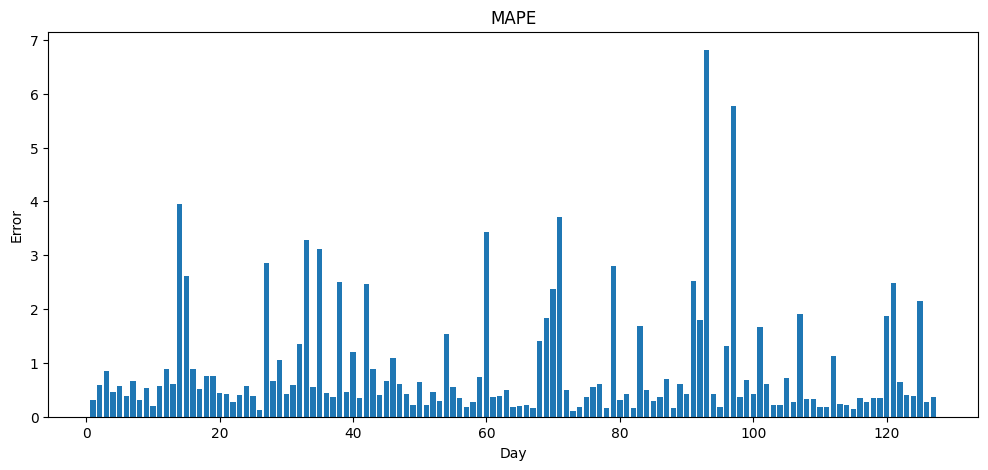

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_Rear1)+1), real_mape_Rear1)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

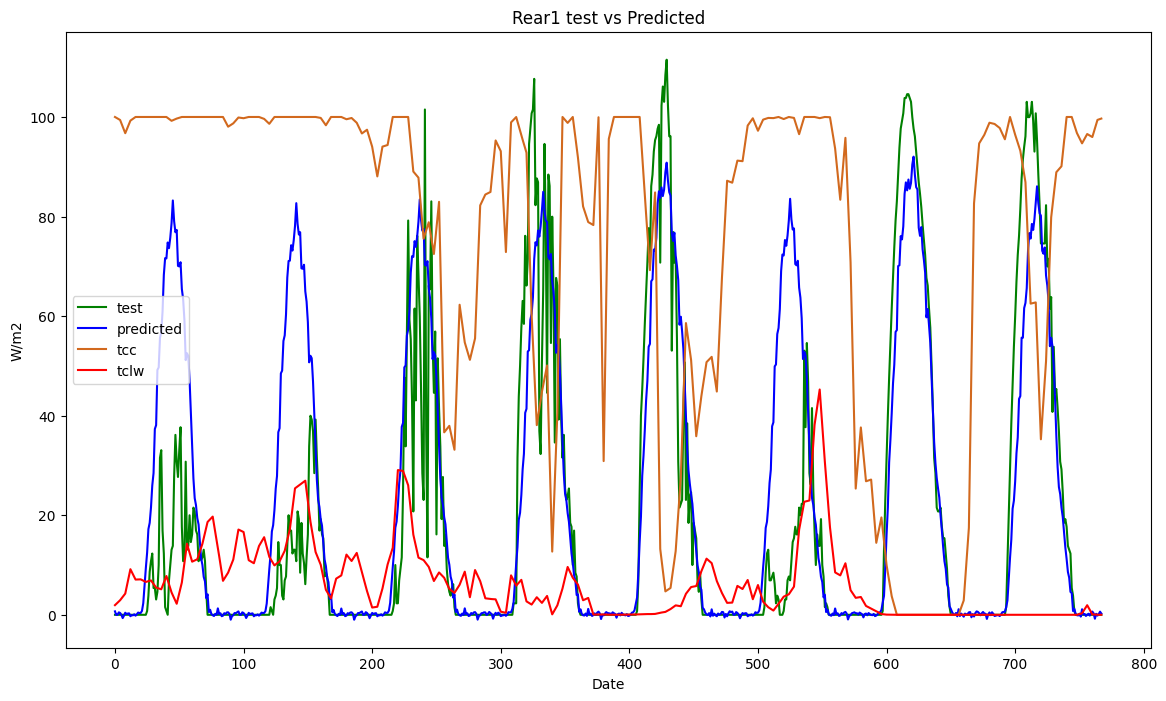

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_Rear1_test.shape[0]*yR_Rear1_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_Rear1_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_Rear1_p1.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*50,label='tclw',color='red')
plt.title("Rear1 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

In [ ]:
model1_Rear1_GRU4.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 384, 64)   │     15,360 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384, 64)   │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 32)        │      9,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96)        │      3,168 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 96)        │     12,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Irr_output (Dense)  │ (None, 96)        │      9,312 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 49,792 (194.50 KB)

 Trainable params: 49,792 (194.50 KB)

 Non-trainable params: 0 (0.00 B)

Retraining in case you need it

In [ ]:
X1_Rear1_train=np.concatenate((X1_Rear1_train,X1_Rear1_val),axis=0)
y1_Rear1_train=np.concatenate((y1_Rear1_train,y1_Rear1_val),axis=0)
surf_Rear1_train=np.concatenate((surf_Rear1_train,surf_Rear1_val),axis=0)

print(X1_Rear1_train.shape)
print(y1_Rear1_train.shape)
print(surf_Rear1_train.shape)

(1141, 384, 14)
(1141, 96)
(1141, 4)


In [ ]:
model1_Rear1_GRU4_v2=create_model_rear([X1_Rear1_train,surf_Rear1_train],y1_Rear1_train,70,0.001,check_point_rear1)

Epoch 1/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.1103 - mae: 0.1103 - mape: 81.2867 - mse: 0.0317
Epoch 2/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0498 - mae: 0.0498 - mape: 39.2059 - mse: 0.0079
Epoch 3/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0411 - mae: 0.0411 - mape: 30.6600 - mse: 0.0057
Epoch 4/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0390 - mae: 0.0390 - mape: 28.3489 - mse: 0.0054
Epoch 5/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0377 - mae: 0.0377 - mape: 26.9264 - mse: 0.0053
Epoch 6/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0373 - mae: 0.0373 - mape: 25.8824 - mse: 0.0053
Epoch 7/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0364 - mae: 0.0364 - mape: 24.9514 - mse: 0.0052
Epoch 8/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0358 - mae: 0.0358 - mape: 24.6382 - mse: 0.0051
Epoch 9/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0355 - mae: 0.0355 - mape: 24.5397 - mse: 0.0051
Epoch 10/7

In [ ]:
model1_Rear1_GRU4_v2=load_model("model_checkpoint/best_model_rear1.keras")

Save the model

In [ ]:
model1_Rear1_GRU4_v2.save('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_Rear1_n5_v2.keras')

In [ ]:
model1_Rear1_GRU4_v2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_Rear1_n5_v2.keras')

Prediction and evaluation

In [ ]:
pred_Rear1_p1_v2=model1_Rear1_GRU4_v2.predict([X1_Rear1_test,surf_Rear1_test])
predict_Rear1_p1_v2=(scaler_Rear1.inverse_transform(pred_Rear1_p1_v2.reshape(-1,1))).reshape(pred_Rear1_p1_v2.shape[0],pred_Rear1_p1_v2.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


MAE

In [ ]:
real_loss_Rear1_v2=list_mae(yR_Rear1_test,predict_Rear1_p1_v2)
print(np.mean(real_loss_Rear1_v2))

7.882296537950048


In [ ]:
print(real_loss_Rear1_v2)

[1.666270116399471, 12.815355346626417, 32.123130652795844, 14.222506035109632, 14.043795302263424, 8.888688791922045, 13.570293455133486, 6.3593277665669055, 1.699168913187406, 4.695374414558955, 8.899179912451538, 3.078476563737657, 12.5872401189322, 8.345115560118284, 3.8565013498012823, 45.94620589369189, 12.887514679262019, 20.97254894724162, 19.490666884838816, 10.348483421982271, 7.697854641131606, 2.839571273543776, 5.088125564092653, 4.861217596188276, 4.206765205450403, 2.2358050349143817, 3.241174273428418, 11.10542751005791, 7.787422175026833, 6.191113255063622, 10.741839647896981, 8.932805017238739, 3.9600053446947143, 9.944953960993995, 11.759299661065564, 2.3216266548569826, 5.602592715138539, 13.110271856764966, 7.7283831499534665, 3.1985750948801788, 3.6972545266926757, 4.718729294372159, 3.631297743026346, 4.419421734070622, 8.248511213057476, 11.881218923330797, 9.266806383840597, 6.4080901807311506, 2.504625464486177, 14.294448003220802, 2.3553002621103567, 8.484985

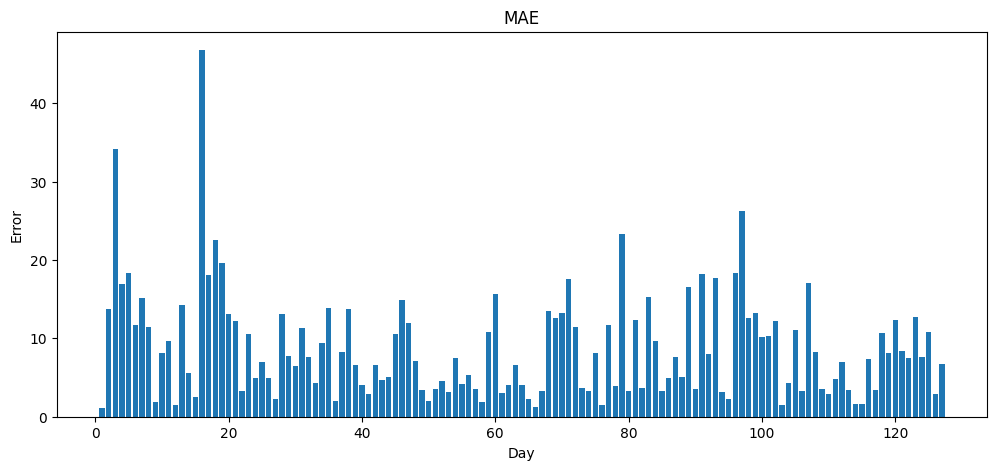

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_Rear1_v2)+1), real_loss_Rear1_v2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_Rear1_v2=list_r2(yR_Rear1_test,predict_Rear1_p1_v2)
print(np.mean(real_r2_Rear1_v2))

-1.7317618862063393


In [ ]:
print(real_r2_Rear1_v2)

[0.9749123321297972, 0.15254162535282323, -0.035837230633867456, 0.47451839556643816, 0.6203405327368146, 0.7214472515695072, 0.14142611841057284, 0.8421993216428316, 0.8667626985814121, 0.8700669426460428, 0.4591461302975648, 0.4681281905528557, 0.09086751462335896, -24.005001522846854, -19.73782299011953, -0.15560373451470677, 0.6838578095103325, 0.2229205257397121, 0.12107752382291581, 0.6894737323499376, 0.7907995306665869, 0.8055026932701632, 0.887584448809536, 0.7704246885702918, 0.88075013203351, 0.9703929456412408, -27.244254260030125, 0.2835553068615422, -0.4464740167157717, 0.4291769150734567, 0.23079650674460284, -2.036610565139888, -10.348114005816159, 0.21813703694768294, -8.29069649533235, 0.6888680088100618, 0.8317971798102521, -7.512511502836645, 0.3047419023165525, 0.4269826316222697, 0.9474288163457466, -0.054388414811542996, -1.8349588642451033, 0.8240656844368245, 0.2802886625741968, -2.9979528072187573, -0.20309780987804782, 0.804567208574454, 0.9776546813378382, 0

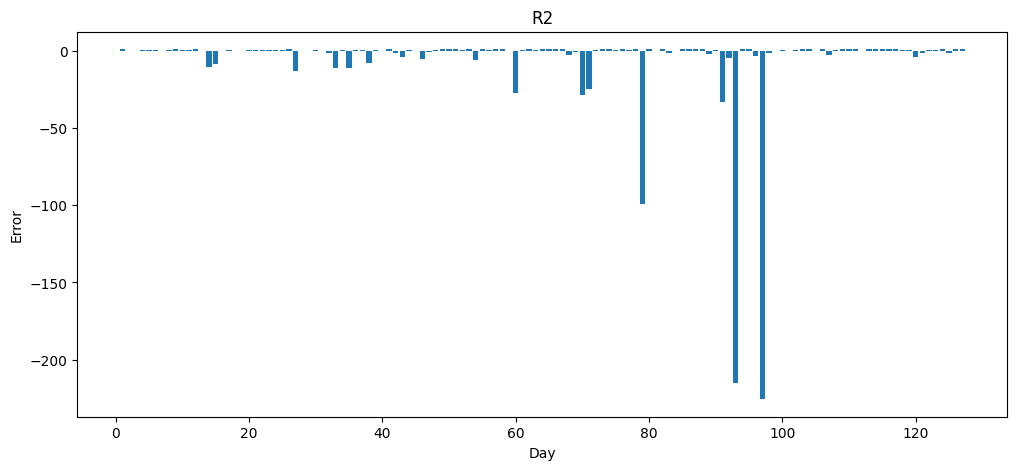

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_Rear1_v2)+1), real_r2_Rear1_v2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_Rear1_v2=mape_mod(yR_Rear1_test,predict_Rear1_p1_v2)
print(np.mean(real_mape_Rear1_v2))

0.8011972042688056


In [ ]:
print(real_mape_Rear1_v2)

[np.float64(0.14797572496304057), np.float64(0.7239097132540119), np.float64(0.863234552437426), np.float64(0.5049512074413796), np.float64(0.5555082988675162), np.float64(0.42258219333758995), np.float64(0.7519828486667661), np.float64(0.3546225349951083), np.float64(0.3139544585555566), np.float64(0.3431605556396927), np.float64(0.6391879567994139), np.float64(0.6326208260954274), np.float64(0.7504175990128725), np.float64(3.6781611026440695), np.float64(1.557876838974549), np.float64(0.9064799461711239), np.float64(0.4370989763272293), np.float64(0.75408045598999), np.float64(0.7847816078189239), np.float64(0.4596727616399071), np.float64(0.3935089021760508), np.float64(0.35730643694878794), np.float64(0.33133712598546705), np.float64(0.5721217923097796), np.float64(0.391935815979074), np.float64(0.18672203319079012), np.float64(1.44989868766343), np.float64(0.7314724155092278), np.float64(1.190802635676076), np.float64(0.5729972682258111), np.float64(0.6962865694382171), np.float64

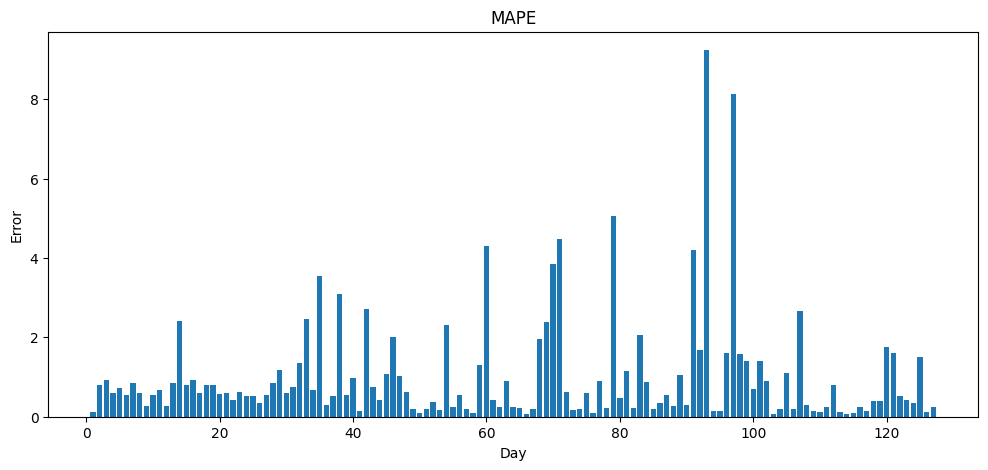

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_Rear1_v2)+1), real_mape_Rear1_v2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

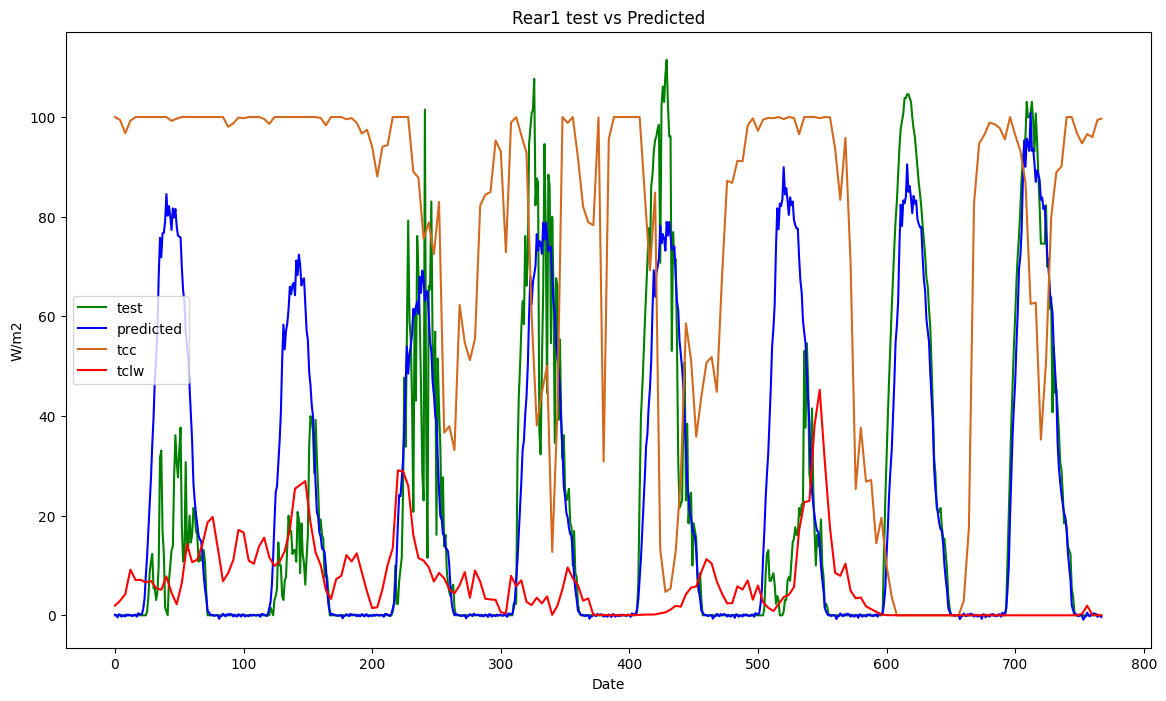

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_Rear1_test.shape[0]*yR_Rear1_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_Rear1_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_Rear1_p1_v2.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*50,label='tclw',color='red')
plt.title("Rear1 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Model summary

In [ ]:
model1_Rear1_GRU4_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 384, 64)   │     15,360 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 384, 64)   │          0 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 32)        │      9,408 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ gru_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 96)        │      3,168 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128)       │          0 │ dense_3[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 96)        │     12,384 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Irr_output (Dense)  │ (None, 96)        │      9,312 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 149,378 (583.51 KB)

 Trainable params: 49,792 (194.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 99,586 (389.01 KB)

LSTM for REAR 2

Define callbacks

In [ ]:
check_point_rear2=ModelCheckpoint(filepath="model_checkpoint/best_model_rear2.keras",monitor='mae',save_best_only=True)

Define object tuner

In [ ]:
tuner_Rear2=BayesianOptimization(create_model_tun_rear,objective='val_loss',max_trials=90,num_initial_points=18,alpha=1e-4,beta=2.6,project_name='gru2_tunv4_d4')

In [ ]:
tuner_Rear2.search([X1_Rear2_train,surf_Rear2_train],y1_Rear2_train,epochs=40,validation_data=([X1_Rear2_val,surf_Rear2_val],y1_Rear2_val),callbacks=[early_stop1])
tuner_Rear2.results_summary()

Trial 90 Complete [00h 00m 24s]
val_loss: 0.026512132957577705

Best val_loss So Far: 0.024366846308112144
Total elapsed time: 00h 46m 43s
Results summary
Results in ./gru2_tunv4_d4
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 32 summary
Hyperparameters:
units1: 64
drop1: 0.3
units2: 128
drop2: 0.2
units3: 96
lr: 0.001
Score: 0.024366846308112144

Trial 11 summary
Hyperparameters:
units1: 64
drop1: 0.3
units2: 128
drop2: 0.2
units3: 96
lr: 0.001
Score: 0.024372350424528122

Trial 66 summary
Hyperparameters:
units1: 64
drop1: 0.3
units2: 128
drop2: 0.2
units3: 96
lr: 0.001
Score: 0.024574505165219307

Trial 49 summary
Hyperparameters:
units1: 64
drop1: 0.2
units2: 32
drop2: 0.1
units3: 64
lr: 0.005
Score: 0.024767007678747177

Trial 87 summary
Hyperparameters:
units1: 128
drop1: 0.3
units2: 64
drop2: 0.3
units3: 96
lr: 0.001
Score: 0.024868447333574295

Trial 28 summary
Hyperparameters:
units1: 64
drop1: 0.3
units2: 128
drop2: 0.2
units3: 96
lr: 0.001
Score:

Define the best model

In [ ]:
model1_Rear2_GRU4=tuner_Rear2.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model1_Rear2_GRU4.save('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_Rear2_n5.keras')

In [ ]:
model1_Rear2_GRU4=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_Rear2_n5.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediction and evaluation

In [ ]:
pred_Rear2_p1=model1_Rear2_GRU4.predict([X1_Rear2_test,surf_Rear2_test])
predict_Rear2_p1=(scaler_Rear2.inverse_transform(pred_Rear2_p1.reshape(-1,1))).reshape(pred_Rear2_p1.shape[0],pred_Rear2_p1.shape[1])

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step


MAE

In [ ]:
real_loss_Rear2=list_mae(yR_Rear2_test,predict_Rear2_p1)
print(np.mean(real_loss_Rear2))

6.982546561706342


In [ ]:
print(real_loss_Rear2)

[6.663766049969446, 8.074405390792327, 25.64071150166068, 11.615943458625727, 12.452700758707985, 7.6583538635991415, 11.49085298232805, 4.006182210909134, 3.3068848813368548, 2.1042476120000533, 4.787476473147969, 3.8415550695162346, 10.343825290696653, 9.069669751815235, 3.6020299506570645, 38.177325457782906, 6.674419980554755, 14.517944190653767, 11.245617294553071, 4.316589182831134, 2.9815997662815925, 1.839767456868289, 3.294663880023954, 4.769979912485062, 2.9480495198627206, 2.6945992134109544, 3.6877076020240644, 9.930497917664518, 9.510261922768452, 5.496705166303516, 8.646239815087847, 8.984093363412386, 3.7139754730491146, 7.799318085885017, 12.520417936078212, 2.9374711264493487, 4.834762314812177, 12.139253764621891, 3.1316858562936205, 4.086972793750923, 2.591322313165129, 4.940405233132448, 3.619121735154264, 6.259672018561638, 9.780260170937712, 12.49097448406057, 10.15960739535313, 5.668540863841088, 4.461797276062158, 12.345492980991603, 3.6665483426468453, 6.016919

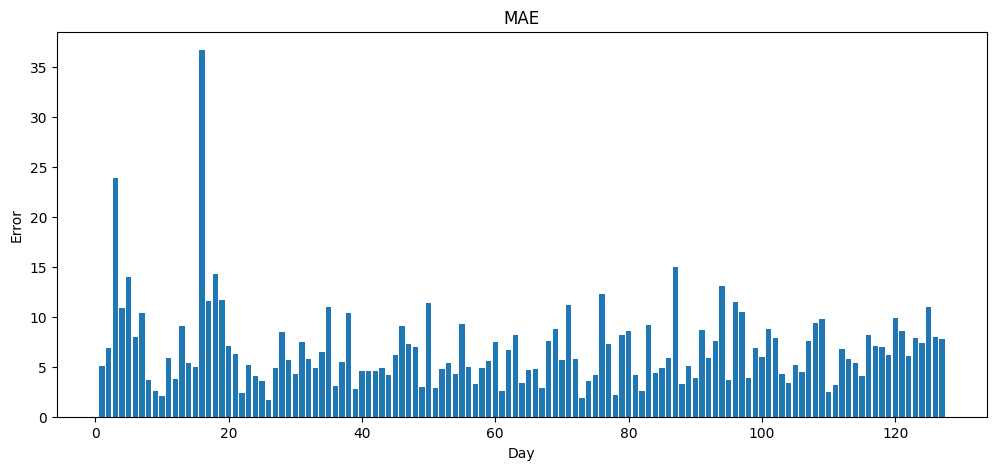

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_Rear2)+1), real_loss_Rear2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_Rear2=list_r2(yR_Rear2_test,predict_Rear2_p1)
print(np.mean(real_r2_Rear2))

-14.352972470186383


In [ ]:
print(real_r2_Rear2)

[0.4308255096016984, 0.17988437680323321, -0.10346505396309258, 0.4841834877782989, 0.6128134091826141, 0.7550284421806746, 0.08926943075176275, 0.909318207751789, 0.15731189544839086, 0.9636354612418413, 0.7209477332657396, -1.0205013325789891, 0.10933314290305585, -154.31954068751216, -164.0229727039181, -0.1766710135345393, 0.8168699576396353, 0.19778459110387137, 0.3028807561216946, 0.9008094551919259, 0.9462862197271502, 0.7846458636879168, 0.925074667077515, 0.49695864724618277, 0.8812829865356703, 0.9335500862326761, -616.9366707755008, 0.132731295551884, -3.5252141771651715, 0.3425957052919071, 0.2004949236291108, -6.636969947746054, -57.26288962027264, 0.2317224651387041, -31.500618140726075, 0.38872901955437966, 0.7581658679807999, -21.923409912076817, 0.5918982709136785, -0.15613393743415127, 0.9572342909076276, -2.0205971063324877, -5.206993677960921, 0.5735727234763125, -1.060366177340304, -11.235211351237785, -2.0323635709212047, 0.754752364993778, 0.8826655765531202, 0.1

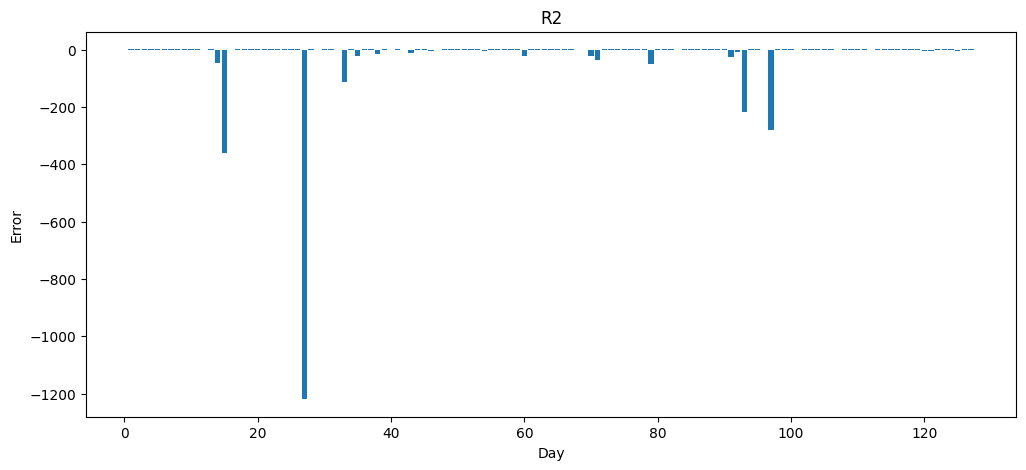

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_Rear2)+1),real_r2_Rear2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_Rear2=mape_mod(yR_Rear2_test,predict_Rear2_p1)
print(np.mean(real_mape_Rear2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_Rear2)

[np.float64(0.6994864577814918), np.float64(0.5878786274531503), np.float64(0.8933771921721451), np.float64(0.4975900847866282), np.float64(0.5418724543844886), np.float64(0.3696463995732136), np.float64(0.729385866574597), np.float64(0.2865766051190126), np.float64(0.9700412441022532), np.float64(0.16670495301095228), np.float64(0.44014962248335354), np.float64(1.1370316905832758), np.float64(0.7559971154555898), np.float64(1.7899883388209306), np.float64(nan), np.float64(0.904472824617634), np.float64(0.3612163344860912), np.float64(0.7414517304811497), np.float64(0.7149879161602096), np.float64(0.3085779960490209), np.float64(0.23532097231729554), np.float64(0.3540551917948426), np.float64(0.25307715087278043), np.float64(0.9646594059530735), np.float64(0.3242160263052036), np.float64(0.2765775171018857), np.float64(nan), np.float64(0.7513826264768221), np.float64(2.273288030916923), np.float64(0.5757269642349326), np.float64(0.7189060963597067), np.float64(2.6852077773710605), np.f

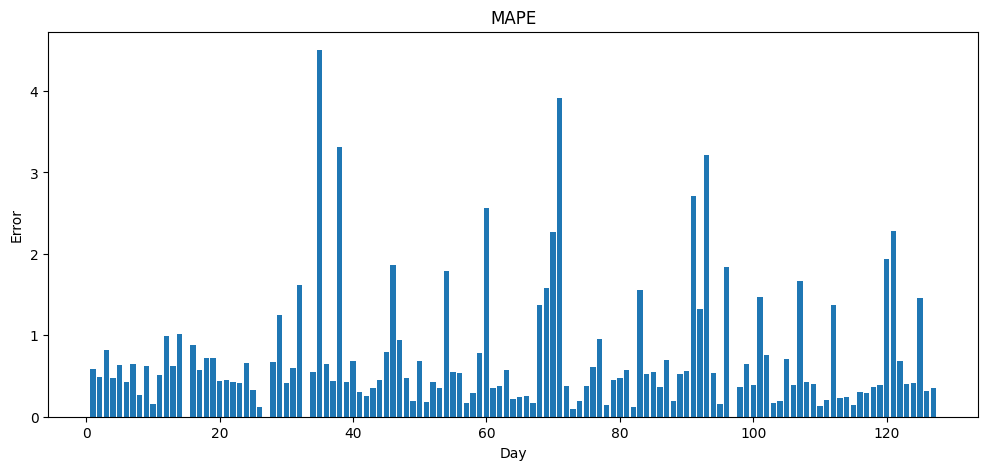

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_Rear2)+1), real_mape_Rear2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

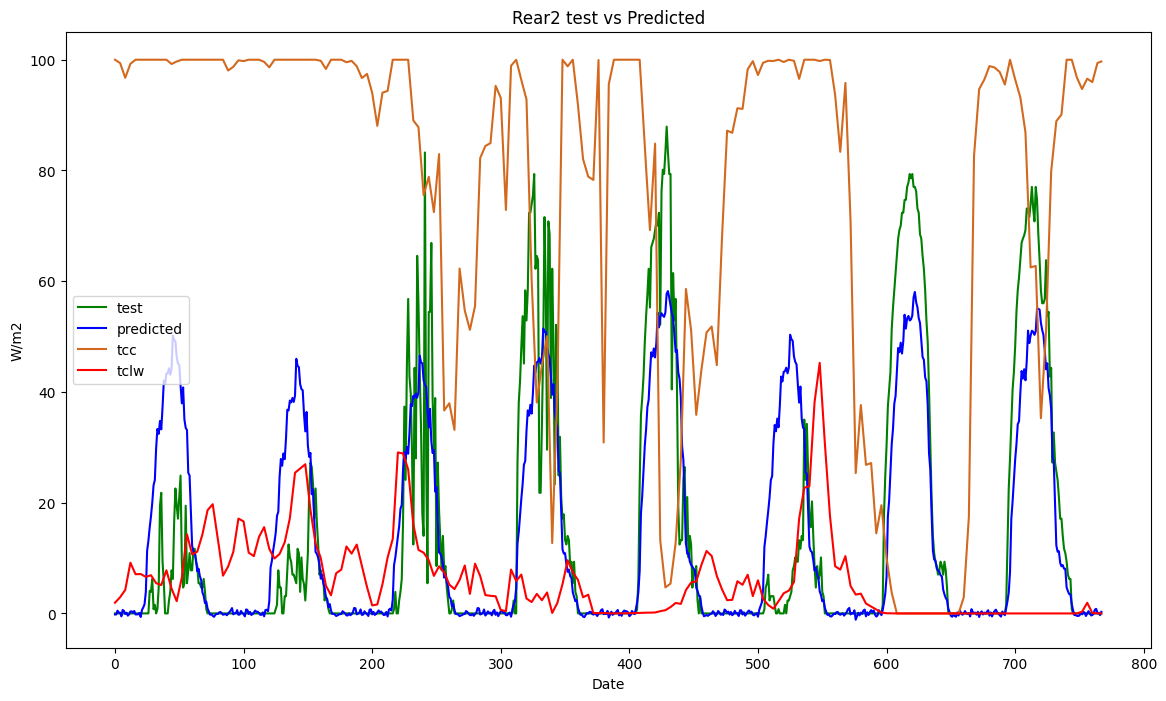

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_Rear2_test.shape[0]*yR_Rear2_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_Rear2_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_Rear2_p1.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*50,label='tclw',color='red')
plt.title("Rear2 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

In [ ]:
model1_Rear2_GRU4.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 384, 64)   │     15,360 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384, 64)   │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 128)       │     74,496 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96)        │     12,384 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 96)        │     12,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Irr_output (Dense)  │ (None, 96)        │      9,312 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 124,096 (484.75 KB)

 Trainable params: 124,096 (484.75 KB)

 Non-trainable params: 0 (0.00 B)

Retraining in case you need it

In [ ]:
X1_Rear2_train=np.concatenate((X1_Rear2_train,X1_Rear2_val),axis=0)
y1_Rear2_train=np.concatenate((y1_Rear2_train,y1_Rear2_val),axis=0)
surf_Rear2_train=np.concatenate((surf_Rear2_train,surf_Rear2_val),axis=0)

print(X1_Rear2_train.shape)
print(y1_Rear2_train.shape)
print(surf_Rear2_train.shape)

(1141, 384, 14)
(1141, 96)
(1141, 4)


In [ ]:
model1_Rear2_GRU4_v2=create_model_rear([X1_Rear2_train,surf_Rear2_train],y1_Rear2_train,70,0.001,check_point_rear2)

Epoch 1/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.1021 - mae: 0.1021 - mape: 87.7644 - mse: 0.0290
Epoch 2/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0519 - mae: 0.0519 - mape: 45.4930 - mse: 0.0086
Epoch 3/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0471 - mae: 0.0471 - mape: 37.7331 - mse: 0.0080
Epoch 4/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0449 - mae: 0.0449 - mape: 34.5703 - mse: 0.0078
Epoch 5/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0430 - mae: 0.0430 - mape: 32.2759 - mse: 0.0076
Epoch 6/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0419 - mae: 0.0419 - mape: 30.9132 - mse: 0.0076
Epoch 7/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0411 - mae: 0.0411 - mape: 30.1580 - mse: 0.0075
Epoch 8/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0403 - mae: 0.0403 - mape: 28.8729 - mse: 0.0073
Epoch 9/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0398 - mae: 0.0398 - mape: 28.6241 - mse: 0.0072
Epoch 10/7

In [ ]:
model1_Rear2_GRU4_v2=load_model("model_checkpoint/best_model_rear2.keras")

Save the model

In [ ]:
model1_Rear2_GRU4_v2.save('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_Rear2_n5_v2.keras')

In [ ]:
model1_Rear2_GRU4_v2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_Rear2_n5_v2.keras')

Prediction and evaluation

In [ ]:
pred_Rear2_p1_v2=model1_Rear2_GRU4_v2.predict([X1_Rear2_test,surf_Rear2_test])
predict_Rear2_p1_v2=(scaler_Rear2.inverse_transform(pred_Rear2_p1_v2.reshape(-1,1))).reshape(pred_Rear2_p1_v2.shape[0],pred_Rear2_p1_v2.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step


MAE

In [ ]:
real_loss_Rear2_v2=list_mae(yR_Rear2_test,predict_Rear2_p1_v2)
print(np.mean(real_loss_Rear2_v2))

6.923899602641066


In [ ]:
print(real_loss_Rear2_v2)

[3.4018985627018874, 8.129969827207894, 25.227467489928756, 13.676545676040684, 16.222565417910342, 11.011990337800698, 11.749434904724817, 9.163277886381747, 1.653777563805323, 5.9320074421964195, 7.320781829943392, 1.7371191420216432, 10.43752763330099, 4.342511836640649, 2.259667608708334, 37.791921064857554, 12.743269771855578, 15.633966038159736, 13.618534098648878, 9.750864385894433, 8.254801370410199, 1.8025790630269762, 7.048797861463046, 4.062701339634464, 5.317231590825771, 5.261499180417073, 1.832979952738917, 9.168085189005723, 2.866845153877501, 5.359232011633819, 8.57397168389383, 2.903732725629455, 2.010973097909258, 7.88216953049389, 3.523063787146745, 1.7187354648493545, 6.693976560495883, 3.3824098874669306, 3.0967790678350084, 2.579665170272784, 8.615077496666073, 2.7414174416953188, 2.0362710753303834, 5.384141853396603, 10.918591209349179, 15.898144565350776, 3.432044979501189, 8.587751020129046, 3.7083051565736636, 12.591311046440941, 4.366412075703308, 6.05426568

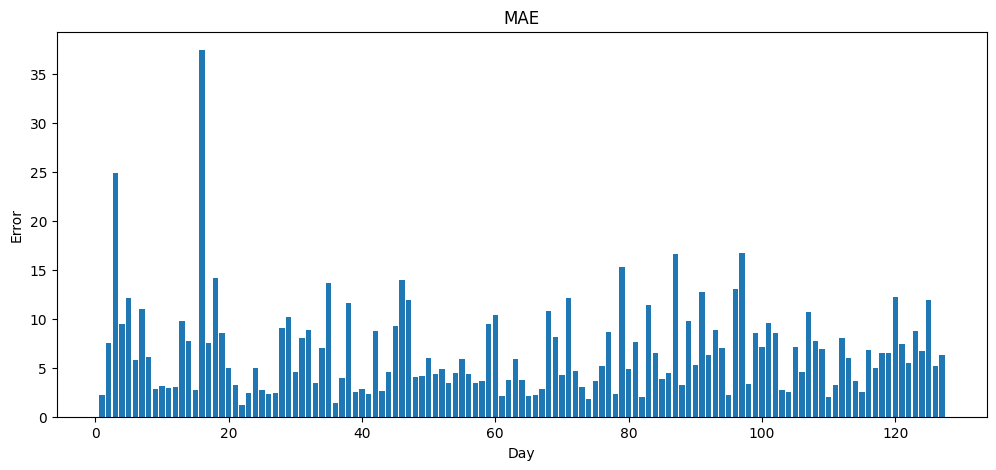

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_Rear2_v2)+1), real_loss_Rear2_v2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_Rear2_v2=list_r2(yR_Rear2_test,predict_Rear2_p1_v2)
print(np.mean(real_r2_Rear2_v2))

-7.250895051441026


In [ ]:
print(real_r2_Rear2_v2)

[0.783545934025603, 0.08294494841132916, -0.12159992094532712, 0.19922114634399224, 0.19302125485156985, 0.34984152145009595, -0.035956504141366974, 0.40640942938515456, 0.7538075799349384, 0.578103193363501, 0.250023554761688, 0.5601375594197286, -0.06802861120108594, -38.14939297226926, -101.21542574427183, -0.18960512623171266, 0.3000715337139147, 0.043985811357653226, -0.06276034799453933, 0.3669520262681907, 0.467426071081956, 0.6843159160563199, 0.5411936781830899, 0.6386663400773116, 0.6056318474654545, 0.6587758933226656, -254.48586985276233, 0.05956335721227546, 0.5844260417248214, 0.19672319341350786, 0.06642118766389093, 0.15478487763109183, -24.99238708851498, 0.041448872551163585, -1.831870810361628, 0.5257956136265975, 0.5221919741612173, -0.8020883036641799, 0.3216798123570931, 0.1907361921573304, 0.4727851737443397, 0.03228111264276401, -1.966686950415872, 0.740484413339584, -1.4840477627697224, -16.884530680948853, 0.6700039944981337, 0.43144990150190043, 0.91931448207

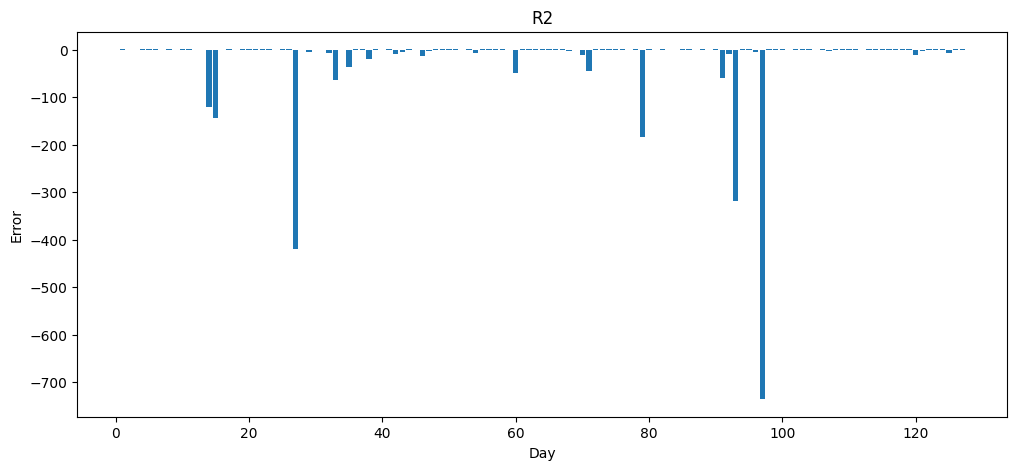

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_Rear2_v2)+1), real_r2_Rear2_v2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_Rear2_v2=mape_mod(yR_Rear2_test,predict_Rear2_p1_v2)
print(np.mean(real_mape_Rear2_v2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_Rear2_v2)

[np.float64(0.373728461723379), np.float64(0.7143211564665916), np.float64(0.9113449695669638), np.float64(0.674325953202805), np.float64(0.7715105293310905), np.float64(0.6929471454649666), np.float64(0.8300063837721778), np.float64(0.6592084156213016), np.float64(0.4821292780115624), np.float64(0.5802291232127639), np.float64(0.7514888207565337), np.float64(0.4849979369807228), np.float64(0.7988358985707504), np.float64(1.3185014293735025), np.float64(nan), np.float64(0.9316915692715162), np.float64(0.6961648695806341), np.float64(0.8333552083715525), np.float64(0.8674118709344877), np.float64(0.6701894507356008), np.float64(0.6457144601481983), np.float64(0.38872072200285834), np.float64(0.6096376305619277), np.float64(0.5471918467728174), np.float64(0.5151764505523638), np.float64(0.5223769881615131), np.float64(nan), np.float64(0.8214073184394066), np.float64(0.5999724540298311), np.float64(0.6908436523090119), np.float64(0.8051145999084562), np.float64(0.8823681445912076), np.flo

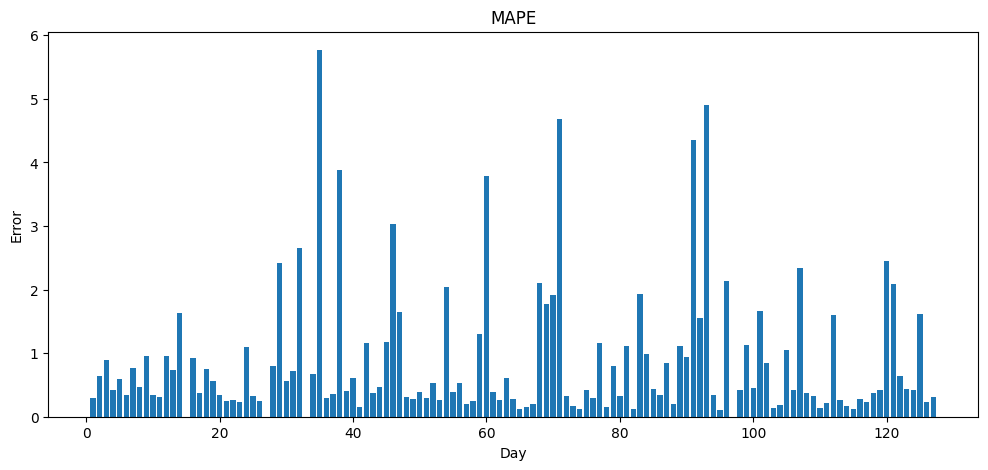

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_Rear2_v2)+1), real_mape_Rear2_v2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

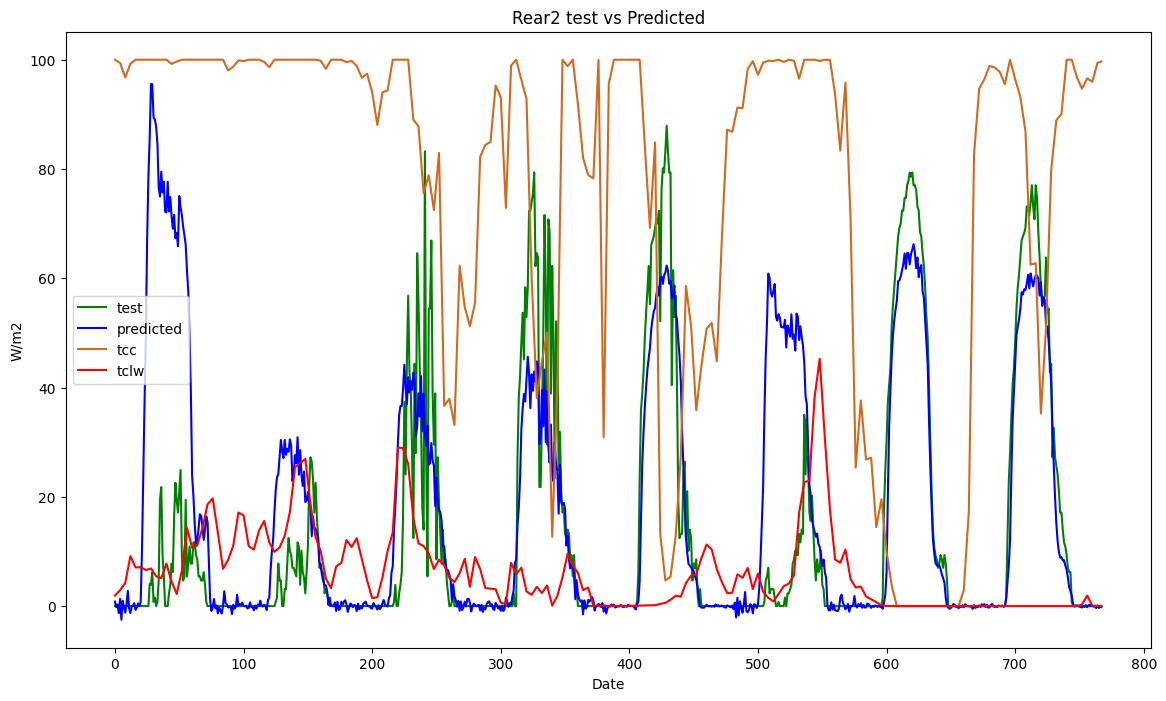

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_Rear2_test.shape[0]*yR_Rear2_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_Rear2_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_Rear2_p1_v2.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*50,label='tclw',color='red')
plt.title("Rear2 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Model summary

In [ ]:
model1_Rear2_GRU4_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 384, 64)   │     15,360 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 384, 64)   │          0 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 128)       │     74,496 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ gru_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 96)        │     12,384 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128)       │          0 │ dense_3[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 96)        │     12,384 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Irr_output (Dense)  │ (None, 96)        │      9,312 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 372,290 (1.42 MB)

 Trainable params: 124,096 (484.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 248,194 (969.51 KB)

LSTM for REAR 3

Define callbaks

In [ ]:
check_point_rear3=ModelCheckpoint(filepath="model_checkpoint/best_model_rear3.keras",monitor='mae',save_best_only=True)

Define object tuner

In [ ]:
tuner_Rear3=BayesianOptimization(create_model_tun_rear,objective='val_loss',max_trials=90,num_initial_points=18,alpha=1e-4,beta=2.6,project_name='gru2_tunv4_d5')

In [ ]:
tuner_Rear3.search([X1_Rear3_train,surf_Rear3_train],y1_Rear3_train,epochs=40,validation_data=([X1_Rear3_val,surf_Rear3_val],y1_Rear3_val),callbacks=[early_stop1])
tuner_Rear3.results_summary()

Trial 90 Complete [00h 00m 52s]
val_loss: 0.023824037984013557

Best val_loss So Far: 0.021906724199652672
Total elapsed time: 01h 17m 29s
Results summary
Results in ./gru2_tunv4_d5
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 32 summary
Hyperparameters:
units1: 64
drop1: 0.2
units2: 64
drop2: 0.3
units3: 128
lr: 0.001
Score: 0.021906724199652672

Trial 43 summary
Hyperparameters:
units1: 128
drop1: 0.1
units2: 128
drop2: 0.3
units3: 128
lr: 0.001
Score: 0.022324685007333755

Trial 53 summary
Hyperparameters:
units1: 64
drop1: 0.3
units2: 128
drop2: 0.3
units3: 128
lr: 0.001
Score: 0.02237660437822342

Trial 82 summary
Hyperparameters:
units1: 64
drop1: 0.3
units2: 128
drop2: 0.3
units3: 128
lr: 0.001
Score: 0.022387642413377762

Trial 81 summary
Hyperparameters:
units1: 64
drop1: 0.3
units2: 128
drop2: 0.3
units3: 128
lr: 0.001
Score: 0.022407105192542076

Trial 27 summary
Hyperparameters:
units1: 64
drop1: 0.1
units2: 64
drop2: 0.3
units3: 128
lr: 0.001
S

Define the best model

In [ ]:
model1_Rear3_GRU4=tuner_Rear3.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Save and Load the model

In [ ]:
model1_Rear3_GRU4.save('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_Rear3_n5.keras')

In [ ]:
model1_Rear3_GRU4=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_Rear3_n5.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediction and evaluation

In [ ]:
pred_Rear3_p1=model1_Rear3_GRU4.predict([X1_Rear3_test,surf_Rear3_test])
predict_Rear3_p1=(scaler_Rear3.inverse_transform(pred_Rear3_p1.reshape(-1,1))).reshape(pred_Rear3_p1.shape[0],pred_Rear3_p1.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step


MAE

In [ ]:
real_loss_Rear3=list_mae(yR_Rear3_test,predict_Rear3_p1)
print(np.mean(real_loss_Rear3))

7.931091582181768


In [ ]:
print(real_loss_Rear3)

[2.031965924501447, 8.249086226709418, 24.232826312004125, 8.852370212471547, 10.386200055265078, 5.962470494673948, 9.372753041549801, 6.1893919472913055, 3.5929091668967454, 4.422410545245673, 6.73453081907527, 3.3358456427378536, 10.048627978502955, 8.175529396730276, 4.996543236294158, 39.61461827026347, 9.251523567334987, 16.493024444351352, 12.845304029072636, 8.354364418129046, 6.857654748328461, 1.839306130514777, 6.288675861217411, 4.651400458501908, 4.626627514877579, 3.2194666787300954, 5.222653673487516, 9.662354069597415, 6.664732811383526, 4.329704627715601, 8.833418938041577, 6.501824132916915, 4.565474926313876, 7.68904803259219, 9.301725423006351, 2.5346403541986255, 8.31403973898673, 8.524104333062203, 3.0665067811588194, 4.3055585588101986, 7.0762847066643175, 5.069357085046875, 4.658456236775625, 5.594433944294818, 6.932356473736431, 9.18187885132347, 6.819033488949061, 10.17927158342534, 4.375522449653273, 15.294414926422263, 4.955793476884426, 5.578609685574871, 6

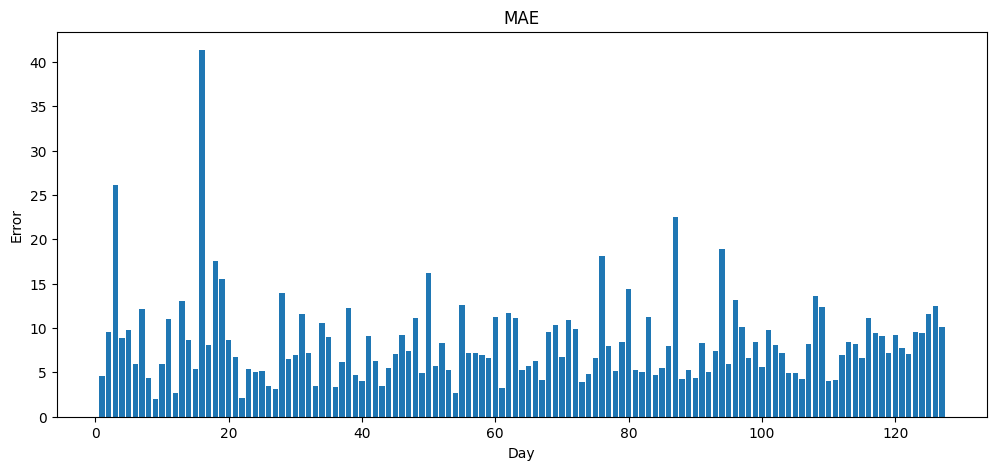

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_Rear3)+1), real_loss_Rear3)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_Rear3=list_r2(yR_Rear3_test,predict_Rear3_p1)
print(np.mean(real_r2_Rear3))

-4.96518315013734


In [ ]:
print(real_r2_Rear3)

[0.9571032221688933, 0.38693604179840646, 0.05626570195040981, 0.5859450854048514, 0.6535651895727821, 0.7939968198689002, 0.29404716000595743, 0.807790229986088, 0.31827970379196346, 0.8707521023471578, 0.6688839453915666, 0.26697857215910237, 0.3351826993749718, -38.78224212912278, -85.60223648474525, -0.09727601837107791, 0.6599446969488232, 0.20836299310000528, 0.3013921683698033, 0.7025952065832582, 0.773804973374882, 0.8465461055065832, 0.8034026195254573, 0.7555314661167377, 0.8406935092299138, 0.9317847099277055, -217.50788836902797, 0.45287362268564124, -0.5557309751219786, 0.6183527065555355, 0.4154025648377109, -1.2082191454214248, -28.128755353256206, 0.452982361612434, -8.376607115582864, 0.6231538992709083, 0.6145042309352061, -4.917224613516915, 0.6742586445549394, 0.09460137733319585, 0.819326105520562, -0.9535747921589672, -6.674706460698276, 0.8527495660635496, 0.5349097399481878, -2.5634496843405805, 0.2163643846172506, 0.537642620868708, 0.9345658472724311, 0.199849

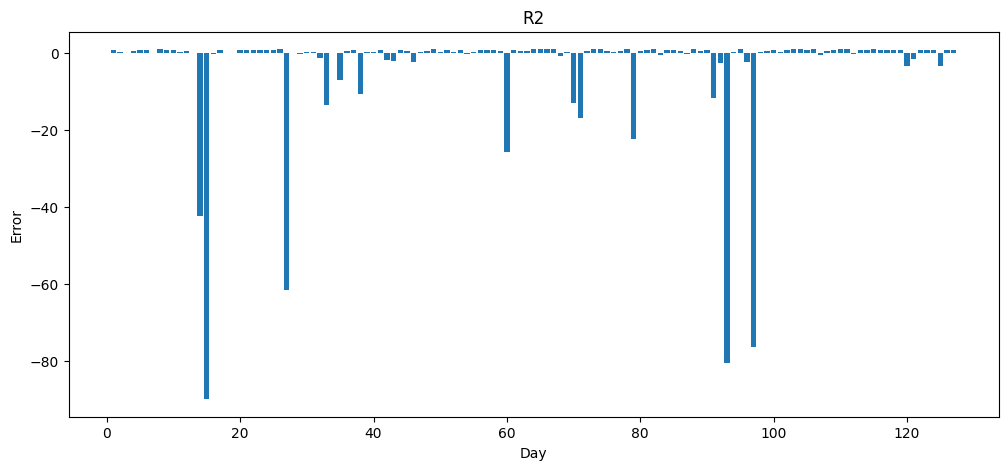

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_Rear3)+1),real_r2_Rear3)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_Rear3=mape_mod(yR_Rear3_test,predict_Rear3_p1)
print(np.mean(real_mape_Rear3))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_Rear3)

[np.float64(0.1872186701037316), np.float64(0.5132670520675032), np.float64(0.8301293620872746), np.float64(0.46168631766934454), np.float64(0.5282496200484144), np.float64(0.37227888203316795), np.float64(0.5895782037726672), np.float64(0.41149153145268946), np.float64(0.8446530317441641), np.float64(0.3086224157141775), np.float64(0.49218556584136336), np.float64(0.6930650746804858), np.float64(0.64711869936675), np.float64(2.2408322017736544), np.float64(1.9106209965740248), np.float64(0.881429852691235), np.float64(0.448300060297737), np.float64(0.7420422030266984), np.float64(0.7075563072537053), np.float64(0.45982540956417334), np.float64(0.4316633670075611), np.float64(0.24725429550170186), np.float64(0.42390473230563763), np.float64(0.6087407368950699), np.float64(0.4449136736691913), np.float64(0.2481795327870424), np.float64(nan), np.float64(0.6389211403409775), np.float64(1.243378871263397), np.float64(0.3944038687264743), np.float64(0.6159854011635324), np.float64(1.3718592

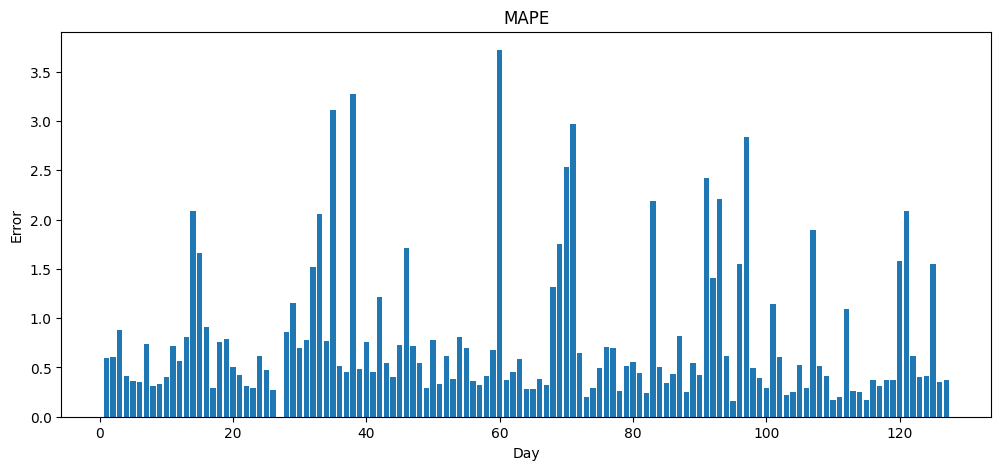

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_Rear3)+1), real_mape_Rear3)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

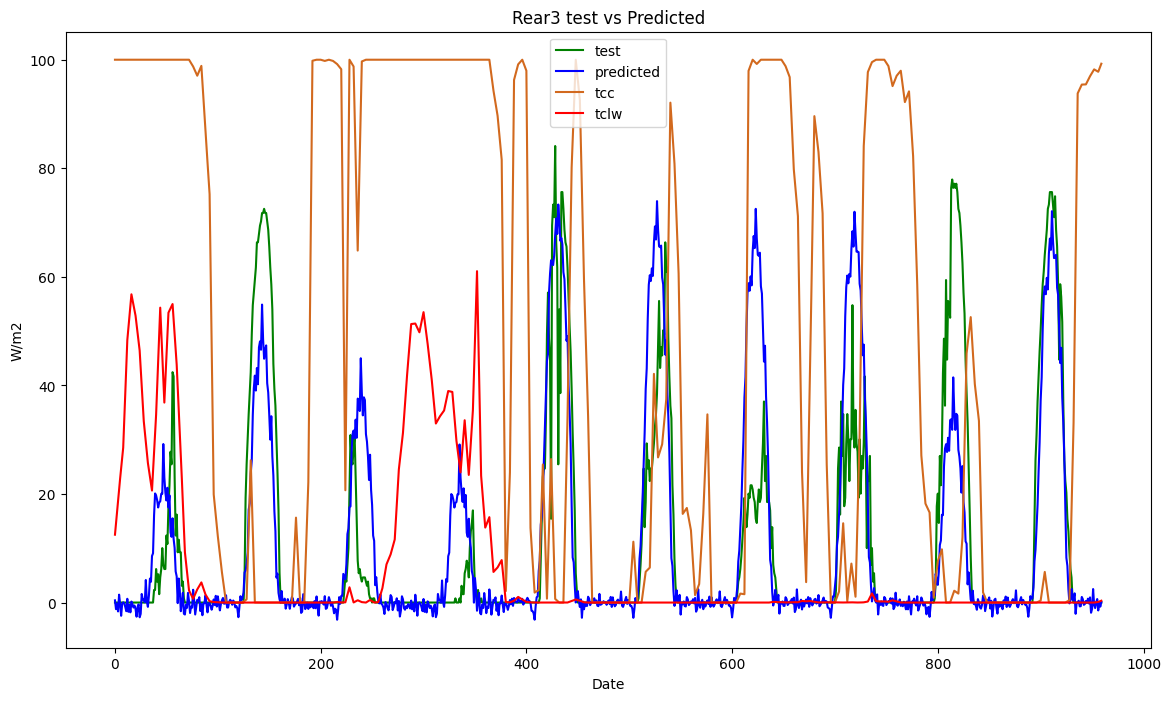

In [ ]:
plt.figure(figsize=(14,8))
st_day=40
end_day=50
dat_clouds=yR_Rear3_test.shape[0]*yR_Rear3_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_Rear3_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_Rear3_p1.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*50,label='tclw',color='red')
plt.title("Rear3 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

In [ ]:
model1_Rear3_GRU4.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 384, 64)   │     15,360 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384, 64)   │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 64)        │     24,960 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      8,320 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 96)        │     15,456 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Irr_output (Dense)  │ (None, 96)        │      9,312 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 73,568 (287.38 KB)

 Trainable params: 73,568 (287.38 KB)

 Non-trainable params: 0 (0.00 B)

Retraining in case you need it

In [ ]:
X1_Rear3_train=np.concatenate((X1_Rear3_train,X1_Rear3_val),axis=0)
y1_Rear3_train=np.concatenate((y1_Rear3_train,y1_Rear3_val),axis=0)
surf_Rear3_train=np.concatenate((surf_Rear3_train,surf_Rear3_val),axis=0)

print(X1_Rear3_train.shape)
print(y1_Rear3_train.shape)
print(surf_Rear3_train.shape)

(1141, 384, 14)
(1141, 96)
(1141, 4)


In [ ]:
model1_Rear3_GRU4_v2=create_model_rear([X1_Rear3_train,surf_Rear3_train],y1_Rear3_train,70,0.001,check_point_rear3)

Epoch 1/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.1025 - mae: 0.1025 - mape: 102.1957 - mse: 0.0273
Epoch 2/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0524 - mae: 0.0524 - mape: 49.7549 - mse: 0.0085
Epoch 3/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0473 - mae: 0.0473 - mape: 39.9819 - mse: 0.0079
Epoch 4/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0446 - mae: 0.0446 - mape: 35.9125 - mse: 0.0075
Epoch 5/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0437 - mae: 0.0437 - mape: 33.9839 - mse: 0.0075
Epoch 6/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0419 - mae: 0.0419 - mape: 32.0668 - mse: 0.0072
Epoch 7/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0407 - mae: 0.0407 - mape: 31.2352 - mse: 0.0070
Epoch 8/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0402 - mae: 0.0402 - mape: 30.5523 - mse: 0.0069
Epoch 9/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0393 - mae: 0.0393 - mape: 29.9635 - mse: 0.0069
Epoch 10/

In [ ]:
model1_Rear3_GRU4_v2=load_model("model_checkpoint/best_model_rear3.keras")

Save the model

In [ ]:
model1_Rear3_GRU4_v2.save('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_Rear3_n5_v2.keras')

In [ ]:
model1_Rear3_GRU4_v2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_Rear3_n5_v2.keras')

Prediction and evaluation

In [ ]:
pred_Rear3_p1_v2=model1_Rear3_GRU4_v2.predict([X1_Rear3_test,surf_Rear3_test])
predict_Rear3_p1_v2=(scaler_Rear3.inverse_transform(pred_Rear3_p1_v2.reshape(-1,1))).reshape(pred_Rear3_p1_v2.shape[0],pred_Rear3_p1_v2.shape[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


MAE

In [ ]:
real_loss_Rear3_v2=list_mae(yR_Rear3_test,predict_Rear3_p1_v2)
print(np.mean(real_loss_Rear3_v2))

7.833965103261955


In [ ]:
print(real_loss_Rear3_v2)

[1.663275000733675, 9.531983996084163, 25.346952038876065, 9.152526152123661, 9.76892318159475, 6.791341540947613, 10.6024382866616, 5.1628427079376, 1.3786549434910844, 7.552404723429149, 8.42884603030359, 1.9092010434520608, 11.39624956253932, 4.676711545223766, 3.5660452456146055, 40.724371713967784, 6.676736876760807, 15.797520847495193, 13.144077394654467, 10.765796488521255, 8.745618592350949, 1.479180408833814, 6.585801672145943, 4.858293458627844, 5.621399169980617, 3.6657381610704736, 3.896686448628003, 11.478766932859484, 7.0740710576125805, 4.821345078453603, 9.488892689480247, 7.132012734869474, 4.196453429174743, 8.688456658760321, 12.518349264554315, 2.250526426521955, 9.16120895989666, 12.558605022397847, 2.8752673364138643, 4.1124983230157675, 4.710210881898353, 4.099507813837657, 4.19080941645946, 4.608594849673433, 8.42299975489439, 12.901299326279648, 12.22147789752952, 10.565313490047638, 1.70319983829235, 14.730312749988675, 2.271526131079155, 5.422737013589753, 6.

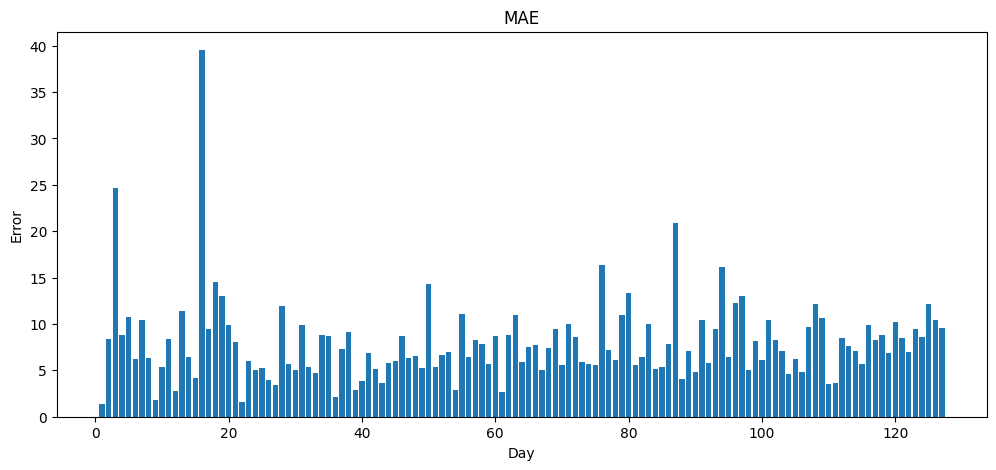

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_Rear3_v2)+1), real_loss_Rear3_v2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
real_r2_Rear3_v2=list_r2(yR_Rear3_test,predict_Rear3_p1_v2)
print(np.mean(real_r2_Rear3_v2))

-3.3391768638931936


In [ ]:
print(real_r2_Rear3_v2)

[0.9686978111140875, 0.2161610661306177, -0.04604855696756105, 0.5326886517886249, 0.6846312983902112, 0.6954932383598629, 0.16677012165993788, 0.8639345660573187, 0.881626501958668, 0.5717366032674992, 0.42556320680316695, 0.6855418042725028, 0.15878658293057668, -12.572310400668654, -47.50591937777997, -0.15700095666361746, 0.7970302253509344, 0.23851167215514424, 0.23672269310897587, 0.46135901125660983, 0.5888116168986143, 0.8556360687611778, 0.7747593049098906, 0.7290399808406026, 0.7481049372333839, 0.9044003240493037, -132.4865086828081, 0.22629138996846954, -0.8128425355881017, 0.5279775909224548, 0.3317167415859513, -1.5374484154376336, -27.31245367753686, 0.32630684694144296, -15.100288455255516, 0.6242720806221548, 0.4985050191486976, -11.269987947724774, 0.6779592725700713, 0.1365399772900494, 0.9139223097054516, -0.30476605815925906, -5.41968084225802, 0.8665078478981705, 0.23943010369907158, -6.0047496512846035, -1.7552582642616548, 0.4949418417709929, 0.9884064876938213,

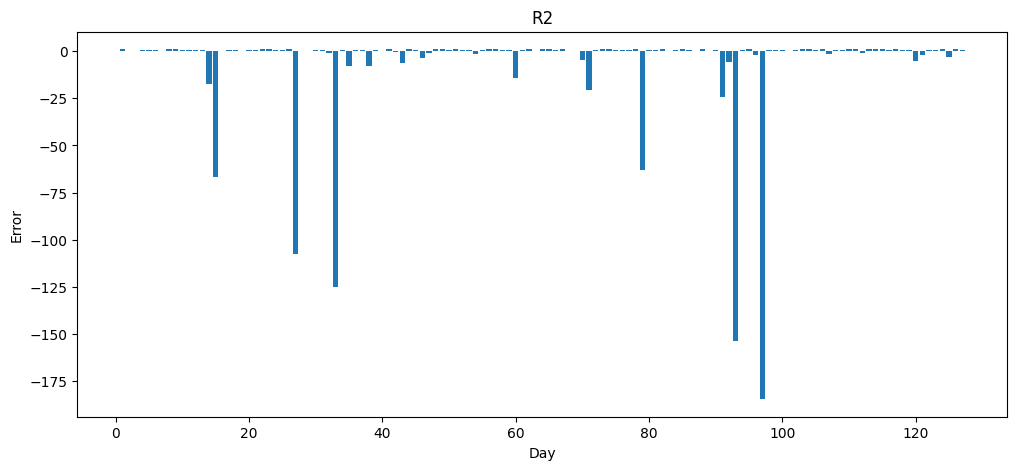

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_Rear3_v2)+1), real_r2_Rear3_v2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
real_mape_Rear3_v2=mape_mod(yR_Rear3_test,predict_Rear3_p1_v2)
print(np.mean(real_mape_Rear3_v2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_Rear3_v2)

[np.float64(0.1964324227173433), np.float64(0.662489435558585), np.float64(0.8691559103399089), np.float64(0.46818034821812476), np.float64(0.4990817221490523), np.float64(0.4147148841186497), np.float64(0.6830050813484587), np.float64(0.3525114769697517), np.float64(0.3167203939410121), np.float64(0.5568496733178115), np.float64(0.6543166801651941), np.float64(0.4067893745799294), np.float64(0.723977158112389), np.float64(1.1513912161933482), np.float64(1.291828636458808), np.float64(0.9081397458247833), np.float64(0.31310483764501773), np.float64(0.731028350515822), np.float64(0.7414271742466163), np.float64(0.5984220646160576), np.float64(0.5388454931135229), np.float64(0.2176104093717676), np.float64(0.43999898221005207), np.float64(0.5310698160842371), np.float64(0.46698277960733586), np.float64(0.2720869116202633), np.float64(nan), np.float64(0.7506047899727799), np.float64(1.299961011777091), np.float64(0.44716731565031426), np.float64(0.6564532524410677), np.float64(1.466624859

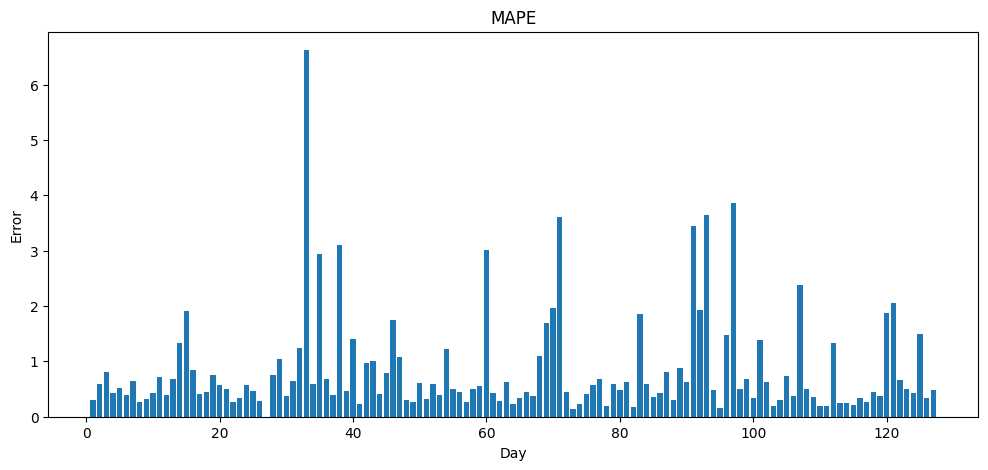

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_Rear3_v2)+1), real_mape_Rear3_v2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

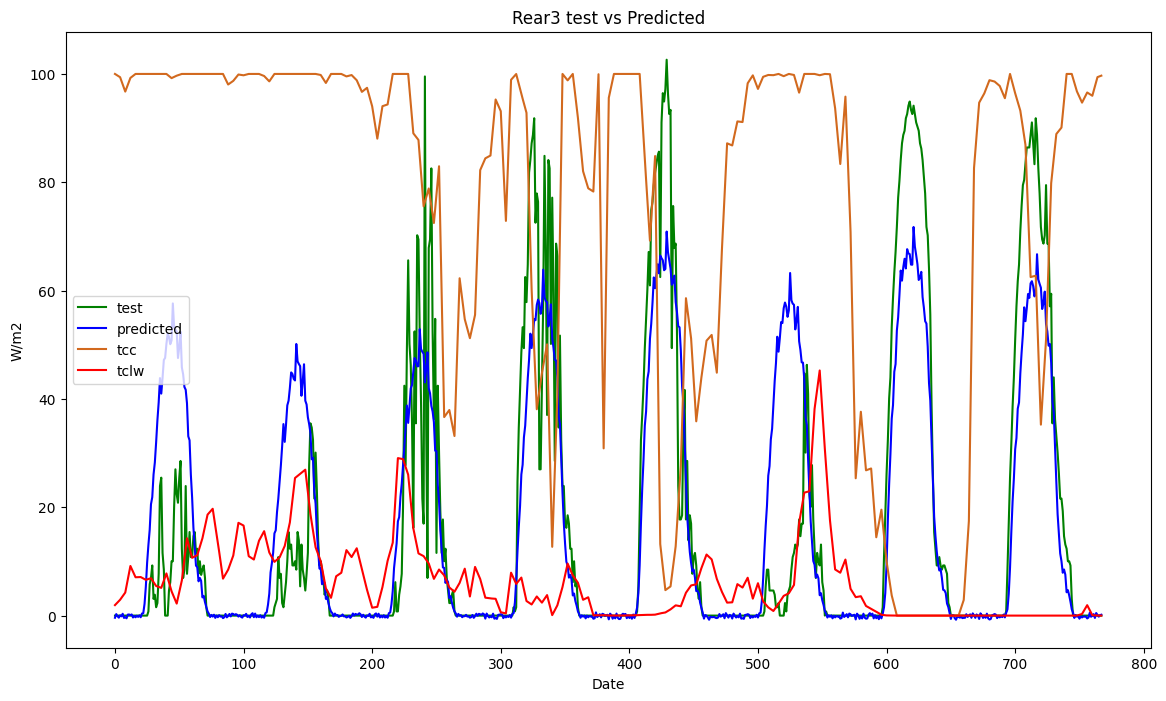

In [ ]:
plt.figure(figsize=(14,8))
st_day=120
end_day=130
dat_clouds=yR_Rear3_test.shape[0]*yR_Rear3_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_Rear3_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_Rear3_p1_v2.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*50,label='tclw',color='red')
plt.title("Rear3 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Model summary

In [ ]:
model1_Rear3_GRU4_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 384, 64)   │     15,360 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 384, 64)   │          0 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 64)        │     24,960 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ gru_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │      8,320 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 160)       │          0 │ dense_3[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 96)        │     15,456 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Irr_output (Dense)  │ (None, 96)        │      9,312 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 220,706 (862.14 KB)

 Trainable params: 73,568 (287.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 147,138 (574.76 KB)